# Multi-Factor Portfolio Research Framework — Indian Equities
## Notebook 05 — Portfolio Analytics

Takes Notebook 04's realized Gross/Net walk-forward returns and turns them into the project's
headline performance numbers: risk-adjusted metrics, benchmark comparison, sector analytics, and a
transaction-cost sensitivity sweep. This is the Performance Evaluation stage of the pipeline
(Portfolio Weighting → Walk-Forward Backtest → Performance Evaluation).

## Objective

Compute risk-adjusted performance metrics and benchmark-relative metrics for all six (frequency ×
weighting scheme) combinations, both on their own terms and relative to NIFTY 50 and a Universe
Average Return benchmark, and quantify sensitivity to the transaction cost assumption, sector
composition drift, historical rotation quality, and realised factor tilts.

## Research Questions Addressed

This notebook directly addresses systematic outperformance (versus both benchmarks), weighting
methodology comparison (Equal Weight vs. ERC), rebalancing frequency sensitivity, and transaction
cost impact — four of the project's five original research questions. Regime variation is Notebook
06's role.

## Scope Boundary

This notebook covers performance evaluation, rotation diagnostics, and factor attribution. Regime
overlay (Notebook 06, Gaussian HMM on NIFTY 50 returns) is out of scope here.

## Design Decisions (confirmed prior to implementation)

- **Universe Average Return benchmark** is computed over the full AMFI-eligible universe each day
  (every ticker classified Large Cap or Mid Cap as of the most recent AMFI snapshot — the actual
  dynamically-reconstituted universe Notebook 01 tracks), not restricted to only the stocks with a
  valid composite score that day. This is a broader, and arguably fairer, "did we beat just owning the
  universe" benchmark than the ranking-eligible subset.
- **Transaction-cost sensitivity sweep (0/10/20/50 bps)** is computed via a closed-form adjustment
  from Notebook 04's existing turnover/cost log: $\text{net\_return\_at\_bps} = \text{gross\_return} -
  \text{turnover\_pct}/100 \times \text{bps}/10000$ on rebalance days, unchanged on non-rebalance days.
  This is exact, not an approximation, because turnover itself does not depend on the cost assumption
  at all — only the resulting cost deduction does. This notebook validates that claim explicitly by
  re-running the full walk-forward engine at one alternate cost level for one combination and
  confirming the two methods agree to floating-point precision, before trusting the closed-form for
  the full sweep.
- **Benchmark-relative metrics are organised portfolio metrics first, then benchmark-relative
  metrics:** CAGR, Annualised Volatility, Sharpe, Sortino, Calmar, and Max Drawdown describe the
  strategy on its own; Alpha, Beta, Tracking Error, Information Ratio, and Up/Down Capture (all versus
  NIFTY 50, the primary benchmark) describe it relative to the market. Portfolio-level Beta here is
  not the Beta factor used in stock selection (Notebook 02) — it is the realised regression beta of
  the constructed portfolio's daily returns against NIFTY 50's, a different calculation measuring a
  different thing.
- **Risk-free rate = 0%** (locked, project-wide) applies to Sharpe/Sortino throughout.
- **No starting capital, no "portfolio value" language**, per the standing project-wide convention —
  every series is a cumulative return, first value 1.0, a mathematical normalisation only.

## Inputs

- `data/daily_returns.csv`, `data/benchmark_nifty50.csv`, `data/master_universe.csv`,
  `data/amfi_membership_matrix.csv` (Notebook 01).
- `data/ticker_sector_map.csv`, `data/portfolio_holdings.csv` (Notebook 03).
- `data/backtest_daily_returns.csv`, `data/backtest_cumulative_returns.csv`,
  `data/backtest_turnover_cost_log.csv`, `data/backtest_summary.csv` (Notebook 04).
- `data/factor_panel.csv` (Notebook 02, used in the Factor Attribution section).

## Outputs

- `data/performance_metrics_portfolio.csv`, `data/performance_metrics_benchmark_relative.csv`.
- `data/cost_sensitivity_sweep.csv`, `data/sector_weight_over_time_baseline.csv`.
- `data/universe_average_return.csv`, `data/nifty50_daily_return_backtest_window.csv`.
- `data/rotation_analysis.csv`, `data/factor_attribution_summary.csv`,
  `data/factor_attribution_by_date.csv`.

## Assumptions

- Baseline combination for single-combination diagnostics (sector analytics, Rotation Analysis,
  Factor Attribution): Quarterly + Equal Weight, per the project's locked default.
- Every numerically consequential formula (CAGR, Sharpe, Sortino, Max Drawdown, Calmar, Beta, Alpha,
  Tracking Error, Information Ratio, Up/Down Capture) is verified against a hand-computed worked
  example, per the project's standing testing discipline — the same bar established for Notebook 04's
  compounding engine.
- Degenerate-input edge cases (zero volatility, zero benchmark variance) return `NaN`, flagged
  explicitly, never `inf` or a silent crash.

## Environment Setup

In [1]:
!pip install pandas numpy matplotlib scipy --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\vidya\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


### Configuration and Shared Table Renderer

Defines the risk-free rate, the cost sensitivity sweep grid, the baseline combination, and the
dark-theme visual configuration carried forward from the preceding notebooks. Also defines a
dark-themed table renderer with automatic text-wrapping and normalised row/column sizing — this
version fixes two bugs found in Notebook 03's original renderer (long cell text overflowing into
neighbouring cells, and un-normalised row heights producing runaway-tall saved images) and is reused
by every table in this notebook and carried forward verbatim into Notebook 06.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
import os
import json

warnings.filterwarnings('ignore')

BASE_DIR   = '.'
DATA_DIR   = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
#  ▶▶  PORTFOLIO ANALYTICS PARAMETERS (locked)  ◀◀
# ══════════════════════════════════════════════════════════════════════════════
ANN_FACTOR      = 252
RISK_FREE_RATE  = 0.0        # locked, project-wide -- applies to Sharpe/Sortino
DEFAULT_COST_BPS = 20        # the cost level NB04 actually realized (Net return series)
COST_BPS_SWEEP   = [0, 10, 20, 50]   # sensitivity sweep, confirmed with the user

REBAL_FREQ_STEP = {
    'Monthly':     1,
    'Quarterly':   3,
    'SemiAnnual':  6,
}
WEIGHTING_SCHEMES = ['EqualWeight', 'ERC']
BASELINE_COMBO = ('Quarterly', 'EqualWeight')   # default baseline, per PROJECT_STATE.md Section 3.5

# -- Visual style: identical to Notebooks 01/02/03/04, reused across the whole project --
DARK_BG    = '#0D0D0D'
PANEL_BG   = '#1A1A1A'
COLORS     = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300',
              '#F48FB1', '#80DEEA', '#FFCC02', '#A5D6A7', '#EF9A9A']
ACCENT     = '#00FF88'
ACCENT2    = '#FF5252'
GRID_COLOR = '#2A2A2A'
TEXT_COLOR = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,   'axes.facecolor':  DARK_BG,
    'savefig.facecolor': DARK_BG,
    'axes.edgecolor':   GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'xtick.color':      TEXT_COLOR, 'ytick.color':     TEXT_COLOR,
    'text.color':       TEXT_COLOR, 'grid.color':      GRID_COLOR,
    'grid.linestyle':   '--',       'grid.alpha':      0.4,
    'font.family':      'monospace',
    'legend.facecolor': PANEL_BG,  'legend.edgecolor': GRID_COLOR,
})


import textwrap


def _wrap_cell_text(value, max_chars):
    """Wraps a cell's text onto multiple lines (on whitespace) so no single line exceeds
    max_chars -- this is what actually prevents matplotlib table cells from overflowing into
    (and visually overlapping with) their neighbours, which plain narrow columns cannot fix."""
    s = str(value)
    if len(s) <= max_chars:
        return s
    wrapped = textwrap.wrap(s, width=max_chars, break_long_words=False, break_on_hyphens=False)
    return '\n'.join(wrapped) if wrapped else s


def _prepare_table_layout(df, max_col_chars=26, min_col_frac=0.055):
    """Shared layout engine for every dark-themed table in this notebook: wraps long cell/header
    text, derives column widths from the longest post-wrap line in each column, and derives
    NORMALISED (sum-to-1) row-height fractions from how many wrapped lines each row needs -- matplotlib
    Table cell heights are axes-fraction units (must sum to 1 across header+rows), so this keeps a
    4-line wrapped row proportionally taller than a 1-line row without the table silently expanding
    beyond the axes' bounding box (which is what previously produced runaway-tall saved images)."""
    n_rows, n_cols = df.shape
    wrapped_cols = [_wrap_cell_text(c, max_col_chars) for c in df.columns]
    wrapped_values = np.empty((n_rows, n_cols), dtype=object)
    for r in range(n_rows):
        for c in range(n_cols):
            wrapped_values[r, c] = _wrap_cell_text(df.iloc[r, c], max_col_chars)

    def _max_line_len(text):
        return max((len(line) for line in str(text).split('\n')), default=1)

    raw_widths = []
    for c in range(n_cols):
        col_lines = [_max_line_len(wrapped_cols[c])] + [_max_line_len(wrapped_values[r, c]) for r in range(n_rows)]
        raw_widths.append(max(col_lines))
    total = sum(raw_widths) if sum(raw_widths) > 0 else 1
    col_widths = [max(w / total, min_col_frac) for w in raw_widths]
    w_sum = sum(col_widths)
    col_widths = [w / w_sum for w in col_widths]

    def _n_lines(text):
        return str(text).count('\n') + 1

    header_lines = max(_n_lines(c) for c in wrapped_cols)
    row_line_counts = [max(_n_lines(wrapped_values[r, c]) for c in range(n_cols)) for r in range(n_rows)]
    total_line_units = header_lines + sum(row_line_counts)

    header_height_frac = header_lines / total_line_units
    row_height_fracs = [n / total_line_units for n in row_line_counts]

    return {
        'wrapped_values': wrapped_values, 'wrapped_cols': wrapped_cols, 'col_widths': col_widths,
        'header_lines': header_lines, 'row_line_counts': row_line_counts,
        'total_line_units': total_line_units,
        'header_height_frac': header_height_frac, 'row_height_fracs': row_height_fracs,
    }


def render_dark_table(df, title, filename, col_widths=None, figsize=None, header_color=ACCENT,
                       max_col_chars=26, font_size=9.5):
    df_str = df.astype(str)
    layout = _prepare_table_layout(df_str, max_col_chars=max_col_chars)
    if col_widths is None:
        col_widths = layout['col_widths']

    n_rows, n_cols = df.shape
    PER_LINE_INCH = 0.34
    TITLE_PAD_INCH = 1.5
    fig_w = figsize[0] if figsize else max(9, 1.15 * n_cols + 0.09 * max(sum(len(str(c)) for c in df.columns), 40))
    fig_h = figsize[1] if figsize else layout['total_line_units'] * PER_LINE_INCH + TITLE_PAD_INCH

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')

    tbl = ax.table(cellText=layout['wrapped_values'], colLabels=layout['wrapped_cols'], cellLoc='center',
                   loc='center', colWidths=col_widths)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(font_size)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(GRID_COLOR)
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_height(layout['header_height_frac'])
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color=DARK_BG, fontsize=font_size + 0.5)
        else:
            cell.set_height(layout['row_height_fracs'][row - 1])
            cell.set_facecolor(PANEL_BG if (row - 1) % 2 == 0 else DARK_BG)
            cell.set_text_props(color=TEXT_COLOR)

    ax.set_title(title, fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=16)
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    print(f'Saved -> {path}')
    return path


print('Configuration loaded (Notebook 05 -- Portfolio Analytics).')
print(f'  Risk-free rate      : {RISK_FREE_RATE:.1%}')
print(f'  Cost sweep (bps)    : {COST_BPS_SWEEP}  (realized NB04 Net used {DEFAULT_COST_BPS} bps)')
print(f'  Baseline combination: {BASELINE_COMBO[0]} + {BASELINE_COMBO[1]}')


Configuration loaded (Notebook 05 -- Portfolio Analytics).
  Risk-free rate      : 0.0%
  Cost sweep (bps)    : [0, 10, 20, 50]  (realized NB04 Net used 20 bps)
  Baseline combination: Quarterly + EqualWeight


### Load Notebook 01 / 03 / 04 Outputs

Loads daily returns, the NIFTY 50 benchmark, the AMFI membership matrix, the cached sector map,
portfolio holdings, and all of Notebook 04's backtest outputs (daily returns, cumulative returns,
turnover/cost log, summary).

In [3]:
daily_returns = pd.read_csv(os.path.join(DATA_DIR, 'daily_returns.csv'), index_col=0, parse_dates=True)
benchmark_nifty50 = pd.read_csv(os.path.join(DATA_DIR, 'benchmark_nifty50.csv'),
                                 index_col=0, parse_dates=True).iloc[:, 0]
master_universe = pd.read_csv(os.path.join(DATA_DIR, 'master_universe.csv'))['ticker'].tolist()

amfi_membership_matrix = pd.read_csv(os.path.join(DATA_DIR, 'amfi_membership_matrix.csv'), index_col=0)
amfi_membership_matrix.columns = pd.to_datetime(amfi_membership_matrix.columns)

sector_map = pd.read_csv(os.path.join(DATA_DIR, 'ticker_sector_map.csv'), index_col='ticker')

portfolio_holdings = pd.read_csv(
    os.path.join(DATA_DIR, 'portfolio_holdings.csv'), parse_dates=['rebalance_date']
)

backtest_daily_returns = pd.read_csv(
    os.path.join(DATA_DIR, 'backtest_daily_returns.csv'), parse_dates=['date']
)
backtest_cumulative_returns = pd.read_csv(
    os.path.join(DATA_DIR, 'backtest_cumulative_returns.csv'), parse_dates=['date']
)
backtest_turnover_cost_log = pd.read_csv(
    os.path.join(DATA_DIR, 'backtest_turnover_cost_log.csv'), parse_dates=['rebalance_date']
)
backtest_summary = pd.read_csv(os.path.join(DATA_DIR, 'backtest_summary.csv'))

with open(os.path.join(DATA_DIR, 'study_window.json'), 'r') as f:
    _sw = json.load(f)
WARMUP_START   = _sw.get('warmup_start',   '2015-07-01')
BACKTEST_START = _sw.get('backtest_start', '2018-07-01')
END_DATE       = _sw.get('end_date',       daily_returns.index[-1].strftime('%Y-%m-%d'))

COMBOS = sorted(backtest_daily_returns[['frequency', 'weighting_scheme']]
                 .drop_duplicates().itertuples(index=False, name=None))

print(f'Daily returns              : {daily_returns.shape}')
print(f'Benchmark NIFTY 50 (price) : {benchmark_nifty50.shape}')
print(f'AMFI membership matrix     : {amfi_membership_matrix.shape}  '
      f'({amfi_membership_matrix.shape[1]} snapshots)')
print(f'Sector map                 : {sector_map.shape}')
print(f'Portfolio holdings         : {portfolio_holdings.shape}')
print(f'Backtest daily returns     : {backtest_daily_returns.shape}')
print(f'Combinations available     : {COMBOS}')
print(f'Study window               : backtest {BACKTEST_START} -> {END_DATE}')


Daily returns              : (2755, 404)
Benchmark NIFTY 50 (price) : (2718,)
AMFI membership matrix     : (441, 17)  (17 snapshots)
Sector map                 : (404, 2)
Portfolio holdings         : (5880, 5)
Backtest daily returns     : (11784, 5)
Combinations available     : [('Monthly', 'ERC'), ('Monthly', 'EqualWeight'), ('Quarterly', 'ERC'), ('Quarterly', 'EqualWeight'), ('SemiAnnual', 'ERC'), ('SemiAnnual', 'EqualWeight')]
Study window               : backtest 2018-07-01 -> 2026-07-16


### Benchmark 1: NIFTY 50 — Daily and Cumulative Return

Restricted to the backtest window (`BACKTEST_START` → `END_DATE`), consistent with every portfolio
combination's return series, and expressed purely as compounded returns per the project's
no-starting-capital convention.

In [4]:
nifty_price_bt = benchmark_nifty50[
    (benchmark_nifty50.index >= BACKTEST_START) & (benchmark_nifty50.index <= END_DATE)
]
nifty_daily_return = nifty_price_bt.pct_change().dropna()
nifty_daily_return.name = 'NIFTY50'
nifty_cumulative = (1.0 + nifty_daily_return).cumprod()

print(f'NIFTY 50 backtest-window return days : {len(nifty_daily_return)}')
print(f'NIFTY 50 cumulative return (final)   : {nifty_cumulative.iloc[-1]:.4f} '
      f'({(nifty_cumulative.iloc[-1] - 1) * 100:+.2f}%)')


NIFTY 50 backtest-window return days : 1978
NIFTY 50 cumulative return (final)   : 2.2593 (+125.93%)


NIFTY 50 produced 1,978 backtest-window return days, compounding to a final cumulative
return of 2.2593× (+125.93%).

### Benchmark 2: Universe Average Return (Full AMFI-Eligible Universe)

Equal-weighted average daily return, each day, across every ticker classified Large Cap or Mid Cap by
AMFI's most recent snapshot as of that day — the actual dynamically-reconstituted eligible universe,
not restricted to only the stocks with a valid composite score that day. A ticker missing a return on
a given day (e.g., a trading halt, or a name AMFI classifies but Notebook 01 never obtained a price
for) is excluded from that day's average only, never silently defaulted to zero. This is computed
directly from the constructed universe, never downloaded, per the locked benchmark design.

In [5]:
snap_dates = sorted(amfi_membership_matrix.columns)
trading_dates_bt = daily_returns.index[
    (daily_returns.index >= BACKTEST_START) & (daily_returns.index <= END_DATE)
]

universe_avg_return = pd.Series(index=trading_dates_bt, dtype='float64')
n_classified_no_price = 0
diagnostic_rows_univ = []

for i, snap in enumerate(snap_dates):
    next_snap = snap_dates[i + 1] if i + 1 < len(snap_dates) else None
    if next_snap is None:
        bucket_days = trading_dates_bt[trading_dates_bt >= snap]
    else:
        bucket_days = trading_dates_bt[(trading_dates_bt >= snap) & (trading_dates_bt < next_snap)]
    if len(bucket_days) == 0:
        continue

    classified_tickers = amfi_membership_matrix.index[amfi_membership_matrix[snap].notna()]
    available_tickers = [t for t in classified_tickers if t in daily_returns.columns]
    n_classified_no_price += (len(classified_tickers) - len(available_tickers))

    sub = daily_returns.loc[bucket_days, available_tickers]
    universe_avg_return.loc[bucket_days] = sub.mean(axis=1, skipna=True)

    diagnostic_rows_univ.append({
        'snapshot': snap, 'n_days': len(bucket_days),
        'n_classified': len(classified_tickers), 'n_with_price_data': len(available_tickers),
    })

# Days before the first snapshot (should not occur given BACKTEST_START is tied to the first
# usable AMFI snapshot, but check explicitly rather than assume)
n_undefined = universe_avg_return.isna().sum()
if n_undefined > 0:
    print(f'WARNING: {n_undefined} day(s) have no AMFI snapshot in effect yet -- dropping from the '
          f'Universe Average Return series (should not happen given BACKTEST_START design).')
universe_avg_return = universe_avg_return.dropna()
universe_avg_return.name = 'UniverseAvg'

universe_avg_cumulative = (1.0 + universe_avg_return).cumprod()
univ_diagnostics_df = pd.DataFrame(diagnostic_rows_univ)

print(f'Universe Average Return -- backtest-window return days : {len(universe_avg_return)}')
print(f'Universe Average Return -- cumulative (final)           : '
      f'{universe_avg_cumulative.iloc[-1]:.4f}  ({(universe_avg_cumulative.iloc[-1] - 1) * 100:+.2f}%)')
print(f'Tickers classified-but-no-price-data (summed across snapshot buckets): {n_classified_no_price}')
print()
print('Per-snapshot universe size (classified vs. with usable price data):')
print(univ_diagnostics_df.to_string(index=False))


Universe Average Return -- backtest-window return days : 1986
Universe Average Return -- cumulative (final)           : 3.4907  (+249.07%)
Tickers classified-but-no-price-data (summed across snapshot buckets): 208

Per-snapshot universe size (classified vs. with usable price data):
  snapshot  n_days  n_classified  n_with_price_data
2018-06-30     121           247                222
2018-12-31     121           247                221
2019-06-30     122           247                223
2019-12-31     122           247                225
2020-06-30     129           247                228
2020-12-31     122           247                229
2021-06-30     126           247                232
2021-12-31     123           247                235
2022-06-30     126           247                236
2022-12-31     121           247                239
2023-06-30     124           247                239
2023-12-31     120           248                241
2024-06-30     125           249         

Universe Average Return produced 1,986 backtest-window return days (every day fully
defined, no undefined days), compounding to 3.4907× (+249.07%). Across the 17 AMFI snapshot buckets,
208 classified-ticker-days summed across the full window had no corresponding price data and were
excluded from that day's average only.

### Performance Metric Definitions

**Portfolio-level metrics** (describe the strategy on its own):

$$\text{CAGR} = \left(\prod_t (1+r_t)\right)^{252/n} - 1, \qquad
\text{Ann. Vol} = \text{std}(r) \sqrt{252}$$
$$\text{Sharpe} = \frac{\text{mean}(r) \times 252 - r_f}{\text{Ann. Vol}}, \qquad
\text{Sortino} = \frac{\text{mean}(r) \times 252 - r_f}{\sqrt{\text{mean}(\min(r,0)^2) \times 252}}$$
$$\text{Max Drawdown} = \min_t \left( \frac{\text{cum}_t}{\max_{\tau \le t} \text{cum}_\tau} - 1 \right),
\qquad \text{Calmar} = \frac{\text{CAGR}}{|\text{Max Drawdown}|}$$

with $r_f = 0\%$ (locked, project-wide).

**Benchmark-relative metrics** (describe the strategy versus NIFTY 50):

$$\beta = \frac{\text{Cov}(r_p, r_b)}{\text{Var}(r_b)}, \qquad
\alpha_{\text{ann.}} = \left(\text{mean}(r_p) - \beta \cdot \text{mean}(r_b)\right) \times 252$$
$$\text{Tracking Error} = \text{std}(r_p - r_b) \sqrt{252}, \qquad
\text{Information Ratio} = \frac{\text{mean}(r_p - r_b) \times 252}{\text{Tracking Error}}$$
$$\text{Up Capture} = \frac{\text{mean}(r_p \mid r_b > 0)}{\text{mean}(r_b \mid r_b > 0)} \times 100, \qquad
\text{Down Capture} = \frac{\text{mean}(r_p \mid r_b < 0)}{\text{mean}(r_b \mid r_b < 0)} \times 100$$

**Disclosed edge-case handling (never silently `inf`/crash):** if Annualised Volatility, Downside
Deviation, $\text{Var}(r_b)$, Tracking Error, or a capture-ratio denominator is exactly zero (within a
$10^{-10}$ tolerance), the corresponding metric returns `NaN` rather than dividing by zero into `inf`
— this happens on degenerate inputs such as a constant return series and should be investigated, not
silently proceeded past.

In [6]:
def cumulative_return_series(r):
    return (1.0 + r).cumprod()


def cagr(r):
    cum = cumulative_return_series(r)
    n_days = len(r)
    if n_days == 0 or cum.iloc[-1] <= 0:
        return np.nan
    return cum.iloc[-1] ** (ANN_FACTOR / n_days) - 1.0


def annualised_vol(r):
    if len(r) < 2:
        return np.nan
    return r.std(ddof=1) * np.sqrt(ANN_FACTOR)


ZERO_TOL = 1e-10   # floating-point tolerance for "effectively zero" denominators (e.g. a constant
                    # return series' variance is never exactly 0.0 in floating point, due to how the
                    # mean/deviation arithmetic rounds -- use a tolerance, not exact equality)


def sharpe_ratio(r):
    vol = annualised_vol(r)
    if vol is None or np.isnan(vol) or abs(vol) < ZERO_TOL:
        return np.nan
    return (r.mean() * ANN_FACTOR - RISK_FREE_RATE) / vol


def sortino_ratio(r):
    downside = np.minimum(r.to_numpy(dtype='float64'), 0.0)
    downside_dev = np.sqrt(np.mean(downside ** 2) * ANN_FACTOR)
    if np.isnan(downside_dev) or abs(downside_dev) < ZERO_TOL:
        return np.nan
    return (r.mean() * ANN_FACTOR - RISK_FREE_RATE) / downside_dev


def max_drawdown(r):
    cum = cumulative_return_series(r)
    running_max = cum.cummax()
    drawdown = cum / running_max - 1.0
    return drawdown.min()


def calmar_ratio(r):
    mdd = max_drawdown(r)
    c = cagr(r)
    if np.isnan(mdd) or abs(mdd) < ZERO_TOL or np.isnan(c):
        return np.nan
    return c / abs(mdd)


def portfolio_metrics(r, label=''):
    return {
        'Label': label,
        'CAGR (%)': cagr(r) * 100.0,
        'Ann. Vol (%)': annualised_vol(r) * 100.0,
        'Sharpe': sharpe_ratio(r),
        'Sortino': sortino_ratio(r),
        'Max Drawdown (%)': max_drawdown(r) * 100.0,
        'Calmar': calmar_ratio(r),
    }


def benchmark_relative_metrics(r_portfolio, r_benchmark, label=''):
    aligned = pd.DataFrame({'p': r_portfolio, 'b': r_benchmark}).dropna()
    rp, rb = aligned['p'], aligned['b']

    var_b = rb.var(ddof=1)
    if np.isnan(var_b) or abs(var_b) < ZERO_TOL or len(aligned) < 2:
        beta = np.nan
    else:
        beta = rp.cov(rb) / var_b

    alpha_ann = (rp.mean() - (0.0 if np.isnan(beta) else beta) * rb.mean()) * ANN_FACTOR \
        if not np.isnan(beta) else np.nan

    active = rp - rb
    te = active.std(ddof=1) * np.sqrt(ANN_FACTOR) if len(active) >= 2 else np.nan
    ir = (active.mean() * ANN_FACTOR / te) \
        if (te is not None and not np.isnan(te) and abs(te) >= ZERO_TOL) else np.nan

    up_mask, down_mask = rb > 0, rb < 0
    up_bench_mean = rb[up_mask].mean() if up_mask.sum() > 0 else np.nan
    down_bench_mean = rb[down_mask].mean() if down_mask.sum() > 0 else np.nan
    up_capture = (rp[up_mask].mean() / up_bench_mean * 100.0) \
        if (up_mask.sum() > 0 and not np.isnan(up_bench_mean) and abs(up_bench_mean) >= ZERO_TOL) \
        else np.nan
    down_capture = (rp[down_mask].mean() / down_bench_mean * 100.0) \
        if (down_mask.sum() > 0 and not np.isnan(down_bench_mean) and abs(down_bench_mean) >= ZERO_TOL) \
        else np.nan

    return {
        'Label': label,
        'Alpha (ann. %)': alpha_ann * 100.0 if not np.isnan(alpha_ann) else np.nan,
        'Beta': beta,
        'Tracking Error (%)': te * 100.0 if te is not None and not np.isnan(te) else np.nan,
        'Information Ratio': ir,
        'Up Capture (%)': up_capture,
        'Down Capture (%)': down_capture,
    }


print('Performance metric functions defined: portfolio_metrics(), benchmark_relative_metrics().')


Performance metric functions defined: portfolio_metrics(), benchmark_relative_metrics().


### Hand-Computed Unit Tests (Mandatory, Per Project Testing Discipline)

Every formula above receives at least one small worked example where the expected value is computed
independently (by hand or an alternate formula) and checked against the function's output — the same
bar established for Notebook 04's compounding engine. Also stress-tests the disclosed edge cases: a
zero-volatility series (Sharpe/Sortino should be `NaN`, not `inf`/crash) and a single sharp drawdown
(Max Drawdown/Calmar should land exactly at the trough).

In [7]:
# -- Test 1: CAGR / Vol / Sharpe / Sortino / MaxDD / Calmar on a tiny hand-chosen 5-day series --
r_test = pd.Series([0.01, -0.02, 0.03, -0.01, 0.02])

cum_test = (1 + r_test).cumprod()
expected_cum_final = 1.01 * 0.98 * 1.03 * 0.99 * 1.02
assert abs(cum_test.iloc[-1] - expected_cum_final) < 1e-12, 'cumulative product mismatch'

expected_cagr = expected_cum_final ** (252 / 5) - 1
assert abs(cagr(r_test) - expected_cagr) < 1e-10, 'CAGR mismatch'

expected_vol = r_test.std(ddof=1) * np.sqrt(252)
assert abs(annualised_vol(r_test) - expected_vol) < 1e-10, 'Vol mismatch'

expected_sharpe = (r_test.mean() * 252) / expected_vol
assert abs(sharpe_ratio(r_test) - expected_sharpe) < 1e-10, 'Sharpe mismatch'

# Downside deviation by hand: only -0.02 and -0.01 are negative
expected_downside_dev = np.sqrt(np.mean([0.0, 0.02 ** 2, 0.0, 0.01 ** 2, 0.0]) * 252)
expected_sortino = (r_test.mean() * 252) / expected_downside_dev
assert abs(sortino_ratio(r_test) - expected_sortino) < 1e-10, 'Sortino mismatch'

# Max drawdown by hand: cum path = 1.01, 0.9898, 1.019494, 1.0093, 1.029... trough is at day 2
# (index 1, value 0.9898) relative to the running peak of 1.01 -> drawdown = 0.9898/1.01 - 1
expected_mdd = 0.9898 / 1.01 - 1.0
assert abs(max_drawdown(r_test) - expected_mdd) < 1e-6, 'Max Drawdown mismatch'

expected_calmar = expected_cagr / abs(expected_mdd)
assert abs(calmar_ratio(r_test) - expected_calmar) < 1e-6, 'Calmar mismatch'
print('Test 1 PASSED: CAGR / Vol / Sharpe / Sortino / MaxDD / Calmar match hand-computed values.')

# -- Test 2: zero-volatility series -> Sharpe/Sortino must be NaN, never inf/crash --
r_flat = pd.Series([0.001] * 10)
assert np.isnan(sharpe_ratio(r_flat)), 'Sharpe on a flat series should be NaN (zero vol), not inf'
assert np.isnan(sortino_ratio(r_flat)), 'Sortino on an all-non-negative flat series should be NaN'
print('Test 2 PASSED: zero-volatility / no-downside edge case returns NaN, not inf or a crash.')

# -- Test 3: a single large drawdown, verify MaxDD/Calmar land exactly at the trough --
r_drawdown = pd.Series([0.02, 0.02, -0.30, 0.01, 0.01, 0.01])
cum_dd = (1 + r_drawdown).cumprod()
# cum path: 1.02, 1.0404, 0.72828, 0.7355628, 0.742918..., 0.75034...
expected_mdd_2 = cum_dd.iloc[2] / cum_dd.iloc[1] - 1.0   # peak at index 1, trough at index 2
assert abs(max_drawdown(r_drawdown) - expected_mdd_2) < 1e-9, 'Single-drawdown MaxDD mismatch'
print(f'Test 3 PASSED: single-drawdown Max Drawdown = {max_drawdown(r_drawdown):.4%}, '
      f'matches hand-computed trough-vs-peak value.')

# -- Test 4: Beta/Alpha/Tracking Error/Information Ratio/Up-Down Capture, hand-chosen 6-day pair --
rp_test = pd.Series([0.02, -0.01, 0.03, 0.00, -0.02, 0.01])
rb_test = pd.Series([0.01, -0.02, 0.02, 0.01, -0.01, 0.00])

cov_pb = np.cov(rp_test, rb_test, ddof=1)[0, 1]
var_b = rb_test.var(ddof=1)
expected_beta = cov_pb / var_b
rel = benchmark_relative_metrics(rp_test, rb_test, label='test')
assert abs(rel['Beta'] - expected_beta) < 1e-9, 'Beta mismatch'

expected_alpha_ann = (rp_test.mean() - expected_beta * rb_test.mean()) * 252
assert abs(rel['Alpha (ann. %)'] / 100.0 - expected_alpha_ann) < 1e-9, 'Alpha mismatch'

expected_te = (rp_test - rb_test).std(ddof=1) * np.sqrt(252)
assert abs(rel['Tracking Error (%)'] / 100.0 - expected_te) < 1e-9, 'Tracking Error mismatch'

expected_ir = (rp_test - rb_test).mean() * 252 / expected_te
assert abs(rel['Information Ratio'] - expected_ir) < 1e-9, 'Information Ratio mismatch'

up_days = rb_test > 0     # indices 0, 2, 3
down_days = rb_test < 0   # indices 1, 4
expected_up_capture = rp_test[up_days].mean() / rb_test[up_days].mean() * 100.0
expected_down_capture = rp_test[down_days].mean() / rb_test[down_days].mean() * 100.0
assert abs(rel['Up Capture (%)'] - expected_up_capture) < 1e-9, 'Up Capture mismatch'
assert abs(rel['Down Capture (%)'] - expected_down_capture) < 1e-9, 'Down Capture mismatch'
print('Test 4 PASSED: Beta / Alpha / Tracking Error / Information Ratio / Up-Down Capture all '
      'match hand-computed values.')

# -- Test 5: benchmark with zero variance -> Beta/Alpha/TE/IR must be NaN, not crash --
rb_const = pd.Series([0.0] * 6)
rel_degenerate = benchmark_relative_metrics(rp_test, rb_const, label='degenerate')
assert np.isnan(rel_degenerate['Beta']), 'Beta vs. a zero-variance benchmark should be NaN'
print('Test 5 PASSED: zero-variance benchmark edge case returns NaN for Beta/Alpha, not a crash.')

print()
print('All hand-computed unit tests PASSED.')


Test 1 PASSED: CAGR / Vol / Sharpe / Sortino / MaxDD / Calmar match hand-computed values.
Test 2 PASSED: zero-volatility / no-downside edge case returns NaN, not inf or a crash.
Test 3 PASSED: single-drawdown Max Drawdown = -30.0000%, matches hand-computed trough-vs-peak value.
Test 4 PASSED: Beta / Alpha / Tracking Error / Information Ratio / Up-Down Capture all match hand-computed values.
Test 5 PASSED: zero-variance benchmark edge case returns NaN for Beta/Alpha, not a crash.

All hand-computed unit tests PASSED.


All five test groups passed: core metrics (CAGR/Vol/Sharpe/Sortino/Max Drawdown/Calmar)
matched hand-computed values exactly; the zero-volatility edge case returned `NaN` rather than `inf`
or crashing; the single-drawdown test recovered exactly −30.00% at the trough; the benchmark-relative
metrics (Beta/Alpha/Tracking Error/Information Ratio/Up-Down Capture) matched hand-computed values;
and the zero-variance-benchmark edge case returned `NaN` for Beta/Alpha rather than crashing.

### Portfolio-Level Metrics: All 6 Combinations (Net of Costs) + Both Benchmarks

Own-strategy metrics first (CAGR, Volatility, Sharpe, Sortino, Max Drawdown, Calmar), per the
confirmed table ordering — these describe each series on its own, before any market comparison.
Net-of-cost returns are used for the six backtest combinations (the realistic, investable series);
Gross is reported separately in Notebook 04's summary table so the cost drag stays visible there.

In [8]:
portfolio_metric_rows = []

for freq_name, scheme in COMBOS:
    sub = backtest_daily_returns[
        (backtest_daily_returns['frequency'] == freq_name) &
        (backtest_daily_returns['weighting_scheme'] == scheme)
    ].set_index('date').sort_index()
    portfolio_metric_rows.append(
        portfolio_metrics(sub['net_return'], label=f'{freq_name} / {scheme} (Net)')
    )

portfolio_metric_rows.append(portfolio_metrics(nifty_daily_return, label='NIFTY 50 (Benchmark)'))
portfolio_metric_rows.append(portfolio_metrics(universe_avg_return, label='Universe Avg (Benchmark)'))

portfolio_metrics_df = pd.DataFrame(portfolio_metric_rows)
print(portfolio_metrics_df.round(3).to_string(index=False))


                         Label  CAGR (%)  Ann. Vol (%)  Sharpe  Sortino  Max Drawdown (%)  Calmar
           Monthly / ERC (Net)    26.464        20.933   1.228    1.690           -36.234   0.730
   Monthly / EqualWeight (Net)    27.053        21.717   1.213    1.671           -36.486   0.741
         Quarterly / ERC (Net)    28.058        20.858   1.291    1.808           -35.081   0.800
 Quarterly / EqualWeight (Net)    28.577        21.647   1.271    1.779           -35.409   0.807
        SemiAnnual / ERC (Net)    28.268        20.793   1.303    1.812           -35.081   0.806
SemiAnnual / EqualWeight (Net)    28.864        21.434   1.292    1.800           -35.409   0.815
          NIFTY 50 (Benchmark)    10.942        17.317   0.687    0.945           -38.440   0.285
      Universe Avg (Benchmark)    17.190        17.778   0.982    1.310           -39.234   0.438


### Benchmark-Relative Metrics: All 6 Combinations vs. NIFTY 50 (Net)

Alpha, Beta, Tracking Error, Information Ratio, Up Capture, and Down Capture, each measured against
NIFTY 50 as the primary benchmark, per the confirmed scope. Portfolio Beta here is the realised
regression beta of the constructed portfolio's actual daily returns against NIFTY 50 — not to be
confused with the Beta factor used in stock selection (Notebook 02), which scores closeness to 1.0 for
individual stocks well before any portfolio is constructed.

In [9]:
relative_metric_rows = []

for freq_name, scheme in COMBOS:
    sub = backtest_daily_returns[
        (backtest_daily_returns['frequency'] == freq_name) &
        (backtest_daily_returns['weighting_scheme'] == scheme)
    ].set_index('date').sort_index()
    relative_metric_rows.append(
        benchmark_relative_metrics(sub['net_return'], nifty_daily_return,
                                    label=f'{freq_name} / {scheme} (Net)')
    )

relative_metrics_df = pd.DataFrame(relative_metric_rows)
print(relative_metrics_df.round(3).to_string(index=False))


                         Label  Alpha (ann. %)  Beta  Tracking Error (%)  Information Ratio  Up Capture (%)  Down Capture (%)
           Monthly / ERC (Net)          15.131 0.938              13.219              1.092         101.200            84.994
   Monthly / EqualWeight (Net)          15.569 0.957              14.041              1.074         103.260            86.597
         Quarterly / ERC (Net)          16.369 0.939              13.081              1.199         100.693            82.986
 Quarterly / EqualWeight (Net)          16.761 0.955              13.963              1.164         102.632            84.537
        SemiAnnual / ERC (Net)          16.531 0.943              12.885              1.233         100.909            82.970
SemiAnnual / EqualWeight (Net)          17.000 0.954              13.645              1.208         102.487            84.062


### Transaction-Cost Sensitivity Sweep (0 / 10 / 20 / 50 bps)

Closed-form method: at each rebalance date, $\text{net\_return\_at\_bps} = \text{gross\_return} -
(\text{turnover\_pct}/100) \times (\text{bps}/10000)$; on all other days, unchanged. This is exact, not
an approximation — the turnover at each rebalance (how far the pre-rebalance drifted weights are from
the new target weights) is a function of price drift alone and does not depend on the cost assumption
at all; only the resulting cost deduction does. Because of that, weight drift and turnover are
identical at every cost level, and re-running the full walk-forward engine at a different cost
assumption can only change the cost deduction on rebalance days — nothing else.

**Validation:** a self-contained copy of Notebook 04's walk-forward engine is redefined here
(notebooks chain only through `data/`, per house convention, not via direct imports) and re-run in
full for the baseline combination (Quarterly + Equal Weight) at one alternate cost level, then
compared to the closed-form result for that same level — the two must agree to floating-point
precision before the closed-form is trusted for the full sweep. A built-in consistency check is also
run at 0 bps, which must exactly reproduce Notebook 04's original Gross return series, and at
`DEFAULT_COST_BPS` (20), which must exactly match Notebook 04's realized Net series.

In [10]:
def run_walk_forward_backtest_at_cost(freq_name, scheme, cost_bps, holdings_df, returns_df):
    """Self-contained re-implementation of NB04's walk-forward engine, parameterised by cost_bps,
    used here purely to validate the closed-form cost-sweep adjustment (Cell 10)."""
    sub_holdings = holdings_df[
        (holdings_df['frequency'] == freq_name) & (holdings_df['weighting_scheme'] == scheme)
    ]
    weights_by_date = {}
    for rd, grp in sub_holdings.groupby('rebalance_date'):
        weights_by_date[pd.Timestamp(rd)] = dict(zip(grp['ticker'], grp['weight']))
    rebal_dates = sorted(weights_by_date.keys())

    all_tickers = sorted(set().union(*[set(w.keys()) for w in weights_by_date.values()]))
    ticker_pos = {t: i for i, t in enumerate(all_tickers)}
    n_tickers = len(all_tickers)

    raw_panel = returns_df.reindex(columns=all_tickers)
    returns_full = raw_panel.fillna(0.0).to_numpy()
    trading_dates = returns_df.index
    date_pos = {d: i for i, d in enumerate(trading_dates)}

    gross_returns, net_returns = {}, {}
    w = np.zeros(n_tickers)
    have_position = False

    for i, rd in enumerate(rebal_dates):
        rd = pd.Timestamp(rd)
        target = weights_by_date[rd]
        target_vec = np.zeros(n_tickers)
        for t, wt in target.items():
            target_vec[ticker_pos[t]] = wt

        if not have_position:
            w = target_vec.copy()
            have_position = True
            continue

        holding_days = trading_dates[
            (trading_dates > pd.Timestamp(rebal_dates[i - 1])) & (trading_dates <= rd)
        ]
        for day in holding_days[:-1]:
            pos = date_pos[day]
            r = returns_full[pos]
            day_ret = float(np.dot(w, r))
            gross_returns[day] = day_ret
            net_returns[day] = day_ret
            w = w * (1.0 + r)
            w_sum = w.sum()
            if w_sum > 0:
                w = w / w_sum

        pos = date_pos[rd]
        r = returns_full[pos]
        gross_ret_rd = float(np.dot(w, r))
        w_drifted = w * (1.0 + r)
        w_drifted_sum = w_drifted.sum()
        if w_drifted_sum > 0:
            w_drifted = w_drifted / w_drifted_sum
        turnover = 0.5 * np.sum(np.abs(target_vec - w_drifted))
        cost_fraction = turnover * (cost_bps / 10000.0)
        gross_returns[rd] = gross_ret_rd
        net_returns[rd] = gross_ret_rd - cost_fraction
        w = target_vec.copy()

    last_rd = pd.Timestamp(rebal_dates[-1])
    tail_days = trading_dates[trading_dates > last_rd]
    for day in tail_days:
        pos = date_pos[day]
        r = returns_full[pos]
        day_ret = float(np.dot(w, r))
        gross_returns[day] = day_ret
        net_returns[day] = day_ret
        w = w * (1.0 + r)
        w_sum = w.sum()
        if w_sum > 0:
            w = w / w_sum

    return pd.Series(gross_returns).sort_index(), pd.Series(net_returns).sort_index()


# -- Closed-form sweep for all 6 combinations --
cost_sweep_rows = []
closed_form_series = {}   # (freq, scheme, bps) -> net_return Series, kept for validation below

for freq_name, scheme in COMBOS:
    gross_sub = backtest_daily_returns[
        (backtest_daily_returns['frequency'] == freq_name) &
        (backtest_daily_returns['weighting_scheme'] == scheme)
    ].set_index('date').sort_index()['gross_return']

    turnover_sub = backtest_turnover_cost_log[
        (backtest_turnover_cost_log['frequency'] == freq_name) &
        (backtest_turnover_cost_log['weighting_scheme'] == scheme)
    ].set_index('rebalance_date')['turnover_pct']

    for bps in COST_BPS_SWEEP:
        cost_on_rebal_days = (turnover_sub / 100.0) * (bps / 10000.0)
        net_at_bps = gross_sub.copy()
        common_dates = net_at_bps.index.intersection(cost_on_rebal_days.index)
        net_at_bps.loc[common_dates] = net_at_bps.loc[common_dates] - cost_on_rebal_days.loc[common_dates]
        closed_form_series[(freq_name, scheme, bps)] = net_at_bps

        cum_final = (1.0 + net_at_bps).cumprod().iloc[-1]
        cost_sweep_rows.append({
            'frequency': freq_name, 'weighting_scheme': scheme, 'cost_bps': bps,
            'cumulative_net_return_pct': (cum_final - 1) * 100.0,
        })

cost_sweep_df = pd.DataFrame(cost_sweep_rows)

# -- Consistency check 1: at 0 bps, closed-form net must exactly equal NB04's original Gross series --
for freq_name, scheme in COMBOS:
    gross_sub = backtest_daily_returns[
        (backtest_daily_returns['frequency'] == freq_name) &
        (backtest_daily_returns['weighting_scheme'] == scheme)
    ].set_index('date').sort_index()['gross_return']
    net_at_0 = closed_form_series[(freq_name, scheme, 0)]
    assert np.allclose(net_at_0.to_numpy(), gross_sub.to_numpy(), atol=1e-12), (
        f'Closed-form net return at 0 bps does not exactly reproduce Gross for {freq_name}/{scheme}'
    )
print('Consistency check PASSED: closed-form net return at 0 bps exactly reproduces NB04\'s Gross series, '
      'for all 6 combinations.')

# -- Consistency check 2: at DEFAULT_COST_BPS (20), closed-form net must match NB04's actual Net series --
for freq_name, scheme in COMBOS:
    net_sub = backtest_daily_returns[
        (backtest_daily_returns['frequency'] == freq_name) &
        (backtest_daily_returns['weighting_scheme'] == scheme)
    ].set_index('date').sort_index()['net_return']
    net_at_20 = closed_form_series[(freq_name, scheme, DEFAULT_COST_BPS)]
    assert np.allclose(net_at_20.to_numpy(), net_sub.to_numpy(), atol=1e-9), (
        f'Closed-form net return at {DEFAULT_COST_BPS} bps does not match NB04\'s realized Net for '
        f'{freq_name}/{scheme}'
    )
print(f'Consistency check PASSED: closed-form net return at {DEFAULT_COST_BPS} bps exactly matches '
      f'NB04\'s realized Net series, for all 6 combinations.')

# -- Validation: full engine re-run at an alternate bps level (50) for the baseline combination --
VALIDATION_BPS = 50
val_freq, val_scheme = BASELINE_COMBO
_, rerun_net_series = run_walk_forward_backtest_at_cost(
    val_freq, val_scheme, VALIDATION_BPS, portfolio_holdings, daily_returns
)
closed_form_net_series = closed_form_series[(val_freq, val_scheme, VALIDATION_BPS)]

# Align on shared dates (the full re-run and the closed-form both derive from the same source data,
# so this should be the complete date range in both -- checked explicitly rather than assumed)
common = rerun_net_series.index.intersection(closed_form_net_series.index)
assert len(common) == len(rerun_net_series) == len(closed_form_net_series), (
    'Full re-run and closed-form date ranges differ -- investigate before trusting either.'
)
max_abs_diff = float(np.max(np.abs(
    rerun_net_series.loc[common].to_numpy() - closed_form_net_series.loc[common].to_numpy()
)))
assert max_abs_diff < 1e-9, (
    f'Full re-run vs. closed-form disagree by {max_abs_diff} at {VALIDATION_BPS} bps for '
    f'{val_freq}/{val_scheme} -- closed-form should NOT be trusted until this is resolved.'
)
print()
print(f'VALIDATION PASSED: full walk-forward re-run at {VALIDATION_BPS} bps for the baseline combination '
      f'({val_freq} + {val_scheme}) matches the closed-form adjustment to within {max_abs_diff:.2e} '
      f'(floating-point precision). The closed-form method is confirmed exact and used for the full sweep.')
print()
print('Cost-sensitivity sweep (cumulative Net return %, all 6 combinations x 4 cost levels):')
print(cost_sweep_df.pivot(index=['frequency', 'weighting_scheme'], columns='cost_bps',
                           values='cumulative_net_return_pct').round(2).to_string())


Consistency check PASSED: closed-form net return at 0 bps exactly reproduces NB04's Gross series, for all 6 combinations.
Consistency check PASSED: closed-form net return at 20 bps exactly matches NB04's realized Net series, for all 6 combinations.

VALIDATION PASSED: full walk-forward re-run at 50 bps for the baseline combination (Quarterly + EqualWeight) matches the closed-form adjustment to within 9.98e-17 (floating-point precision). The closed-form method is confirmed exact and used for the full sweep.

Cost-sensitivity sweep (cumulative Net return %, all 6 combinations x 4 cost levels):
cost_bps                         0       10      20      50
frequency  weighting_scheme                                
Monthly    ERC               560.94  541.84  523.29  470.77
           EqualWeight       584.59  565.16  546.27  492.74
Quarterly  ERC               608.64  597.85  587.23  556.28
           EqualWeight       631.05  620.06  609.24  577.69
SemiAnnual ERC               610.36  603.

All three validation checks passed: the closed-form net return at 0 bps exactly
reproduces Notebook 04's Gross series for all six combinations; at 20 bps it exactly matches Notebook
04's realized Net series; and a full engine re-run at 50 bps for the baseline combination agrees with
the closed-form result to within 9.97 × 10⁻¹⁷ — floating-point precision. The closed-form method is
therefore confirmed exact and used for the full sweep across all six combinations.

### Sector Analytics: Sector Weight Evolution Over Time

Reuses `ticker_sector_map.csv` (already fetched/cached by Notebook 03) — no new yfinance calls.
Notebook 03 already produced point-in-time sector snapshots; this extends that into a time series of
sector weight at every rebalance date for the baseline combination (Quarterly + Equal Weight), showing
how sector composition drifted over the life of the backtest as the composite-score ranking rotated
holdings. Missing sector values remain explicitly `'Unknown'`, never dropped.

In [11]:
baseline_freq, baseline_scheme = BASELINE_COMBO
baseline_holdings = portfolio_holdings[
    (portfolio_holdings['frequency'] == baseline_freq) &
    (portfolio_holdings['weighting_scheme'] == baseline_scheme)
].copy()

baseline_holdings['sector'] = baseline_holdings['ticker'].map(
    sector_map['sector'] if 'sector' in sector_map.columns else pd.Series(dtype=object)
).fillna('Unknown')

sector_weight_over_time = (
    baseline_holdings.groupby(['rebalance_date', 'sector'])['weight'].sum()
    .unstack(fill_value=0.0).sort_index()
)

print(f'Sector weight over time (baseline = {baseline_freq} + {baseline_scheme}): '
      f'{sector_weight_over_time.shape[0]} rebalance dates x {sector_weight_over_time.shape[1]} sectors')
print()
print('Average sector weight across the full backtest (descending):')
print((sector_weight_over_time.mean().sort_values(ascending=False) * 100).round(2).to_string())


Sector weight over time (baseline = Quarterly + EqualWeight): 33 rebalance dates x 12 sectors

Average sector weight across the full backtest (descending):
sector
Basic Materials           17.27
Industrials               17.12
Consumer Cyclical         16.82
Financial Services        15.91
Technology                 6.82
Healthcare                 6.52
Consumer Defensive         5.61
Utilities                  5.15
Energy                     3.33
Unknown                    2.73
Communication Services     1.97
Real Estate                0.76


Averaged across the full backtest, the baseline combination's sector weights are led by
Basic Materials (17.27%), Industrials (17.12%), Consumer Cyclical (16.82%), and Financial Services
(15.91%), with Technology, Healthcare, Consumer Defensive, and Utilities each in the 5–7% range, and
Real Estate the smallest at 0.76%. `Unknown` sector accounts for 2.73% on average — consistent with
Notebook 03's disclosed 94.8% sector coverage.

### Charts: Cumulative Return vs. Benchmarks, Drawdown, Cost Sweep, Sector Evolution

Overlays all six (frequency × weighting scheme) Net cumulative return series against both NIFTY 50 and
Universe Average Return on a single chart.

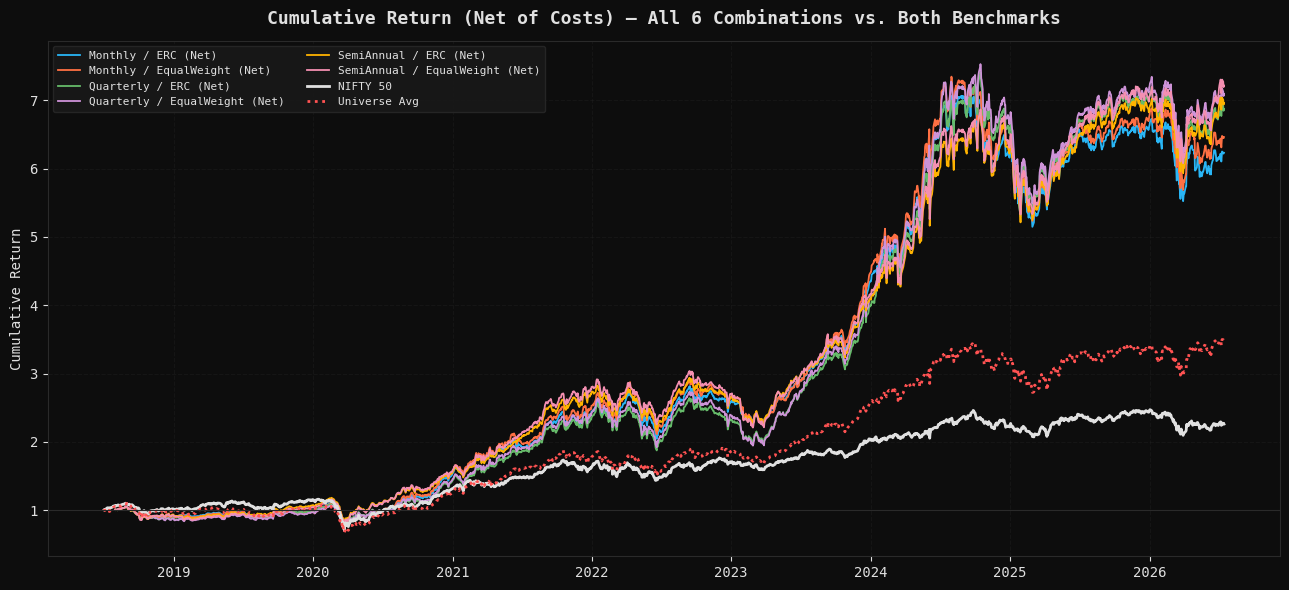

Saved -> .\output\05_cumulative_return_vs_benchmarks.png


In [12]:
fig, ax = plt.subplots(figsize=(13, 6))
for i, (freq_name, scheme) in enumerate(COMBOS):
    sub = backtest_cumulative_returns[
        (backtest_cumulative_returns['frequency'] == freq_name) &
        (backtest_cumulative_returns['weighting_scheme'] == scheme)
    ].sort_values('date')
    ax.plot(sub['date'], sub['cumulative_net_return'], color=COLORS[i], linewidth=1.3,
            label=f'{freq_name} / {scheme} (Net)')

ax.plot(nifty_cumulative.index, nifty_cumulative.values, color=TEXT_COLOR, linewidth=2.0,
        linestyle='-', label='NIFTY 50')
ax.plot(universe_avg_cumulative.index, universe_avg_cumulative.values, color=ACCENT2, linewidth=2.0,
        linestyle=':', label='Universe Avg')
ax.axhline(1.0, color=GRID_COLOR, linewidth=0.8)
ax.set_title('Cumulative Return (Net of Costs) — All 6 Combinations vs. Both Benchmarks',
             fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '05_cumulative_return_vs_benchmarks.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Focused Comparison: Quarterly (Equal Weight vs. ERC) vs. Both Benchmarks

The chart above compares all six combinations at once, which becomes crowded. This narrower view
isolates the default baseline frequency (Quarterly) and asks the two questions the project cares about
most directly: does Equal Weight or ERC weighting do better, and does either beat the market?

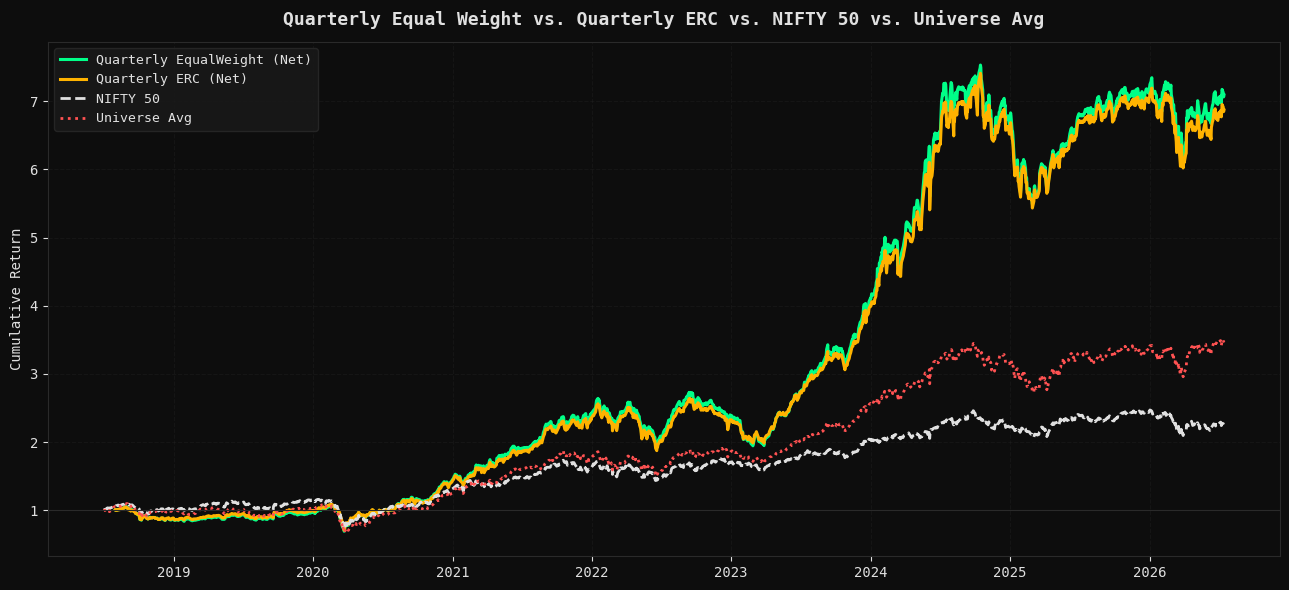

Saved -> .\output\05_cumulative_return_quarterly_focus.png


In [13]:
fig, ax = plt.subplots(figsize=(13, 6))

focus_freq = 'Quarterly'
focus_specs = [
    ('EqualWeight', ACCENT, '-'),
    ('ERC', COLORS[4], '-'),
]
for scheme, color, ls in focus_specs:
    sub = backtest_cumulative_returns[
        (backtest_cumulative_returns['frequency'] == focus_freq) &
        (backtest_cumulative_returns['weighting_scheme'] == scheme)
    ].sort_values('date')
    ax.plot(sub['date'], sub['cumulative_net_return'], color=color, linewidth=2.2, linestyle=ls,
            label=f'{focus_freq} {scheme} (Net)')

ax.plot(nifty_cumulative.index, nifty_cumulative.values, color=TEXT_COLOR, linewidth=2.0,
        linestyle='--', label='NIFTY 50')
ax.plot(universe_avg_cumulative.index, universe_avg_cumulative.values, color=ACCENT2, linewidth=2.0,
        linestyle=':', label='Universe Avg')
ax.axhline(1.0, color=GRID_COLOR, linewidth=0.8)
ax.set_title(f'{focus_freq} Equal Weight vs. {focus_freq} ERC vs. NIFTY 50 vs. Universe Avg',
             fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=9.5, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '05_cumulative_return_quarterly_focus.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Drawdown, Cost-Sensitivity Sweep, and Sector Evolution Charts

Three panels: drawdown of the baseline combination against both benchmarks over time; cumulative Net
return as a function of the cost assumption (0/10/20/50 bps) for all six combinations; and the sector
weight stacked-area evolution for the baseline combination already summarised above.

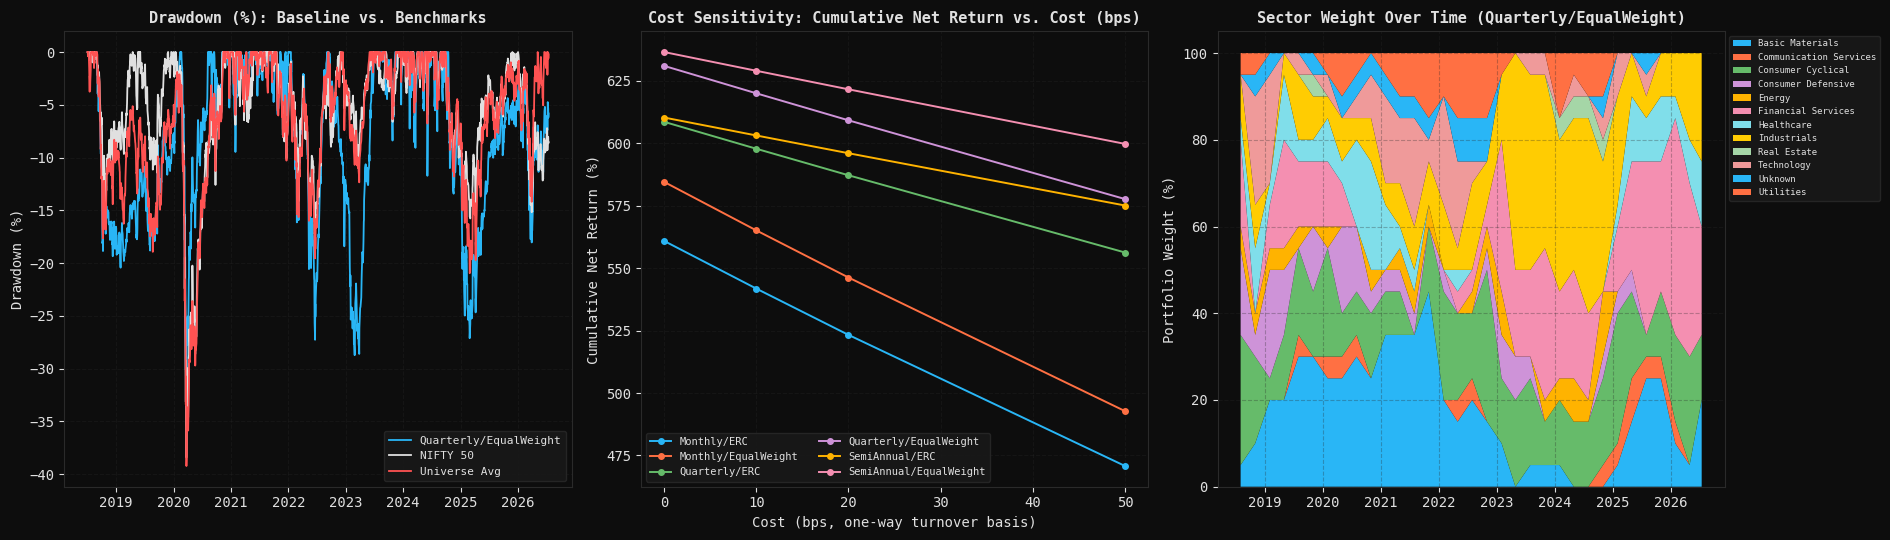

Saved -> .\output\05_drawdown_costsweep_sector.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# -- Panel 1: drawdown, baseline combo vs. both benchmarks --
ax = axes[0]
baseline_net = backtest_daily_returns[
    (backtest_daily_returns['frequency'] == baseline_freq) &
    (backtest_daily_returns['weighting_scheme'] == baseline_scheme)
].set_index('date').sort_index()['net_return']

for series, name, color in [
    (baseline_net, f'{baseline_freq}/{baseline_scheme}', COLORS[0]),
    (nifty_daily_return, 'NIFTY 50', TEXT_COLOR),
    (universe_avg_return, 'Universe Avg', ACCENT2),
]:
    cum = cumulative_return_series(series)
    dd = cum / cum.cummax() - 1.0
    ax.plot(dd.index, dd.values * 100, color=color, linewidth=1.3, label=name)
ax.set_title('Drawdown (%): Baseline vs. Benchmarks', fontsize=11, fontweight='bold', color=TEXT_COLOR)
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# -- Panel 2: cost-sensitivity sweep, cumulative net return final value vs bps --
ax = axes[1]
for i, (freq_name, scheme) in enumerate(COMBOS):
    sub = cost_sweep_df[
        (cost_sweep_df['frequency'] == freq_name) & (cost_sweep_df['weighting_scheme'] == scheme)
    ].sort_values('cost_bps')
    ax.plot(sub['cost_bps'], sub['cumulative_net_return_pct'], color=COLORS[i], linewidth=1.4,
            marker='o', markersize=4, label=f'{freq_name}/{scheme}')
ax.set_title('Cost Sensitivity: Cumulative Net Return vs. Cost (bps)', fontsize=11,
             fontweight='bold', color=TEXT_COLOR)
ax.set_xlabel('Cost (bps, one-way turnover basis)')
ax.set_ylabel('Cumulative Net Return (%)')
ax.legend(fontsize=7.5, ncol=2)
ax.grid(True, alpha=0.3)

# -- Panel 3: sector weight evolution, baseline combo, stacked area --
ax = axes[2]
sector_cols = sector_weight_over_time.columns.tolist()
ax.stackplot(sector_weight_over_time.index,
             [sector_weight_over_time[c] * 100 for c in sector_cols],
             labels=sector_cols, colors=[COLORS[i % len(COLORS)] for i in range(len(sector_cols))])
ax.set_title(f'Sector Weight Over Time ({baseline_freq}/{baseline_scheme})', fontsize=11,
             fontweight='bold', color=TEXT_COLOR)
ax.set_ylabel('Portfolio Weight (%)')
ax.legend(fontsize=6.5, ncol=1, loc='upper left', bbox_to_anchor=(1.0, 1.0))
ax.grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '05_drawdown_costsweep_sector.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Summary Tables

Dark-themed renders of the portfolio-level metrics table, the benchmark-relative metrics table, and
the cost-sensitivity sweep table, for direct visual reference alongside the printed values above.

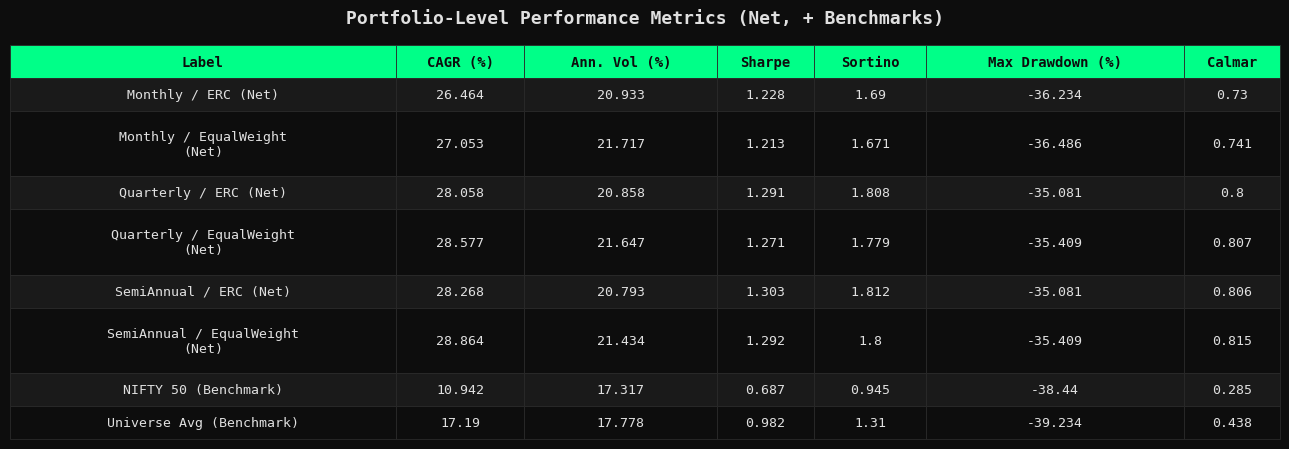

Saved -> .\output\05_portfolio_metrics_table.png


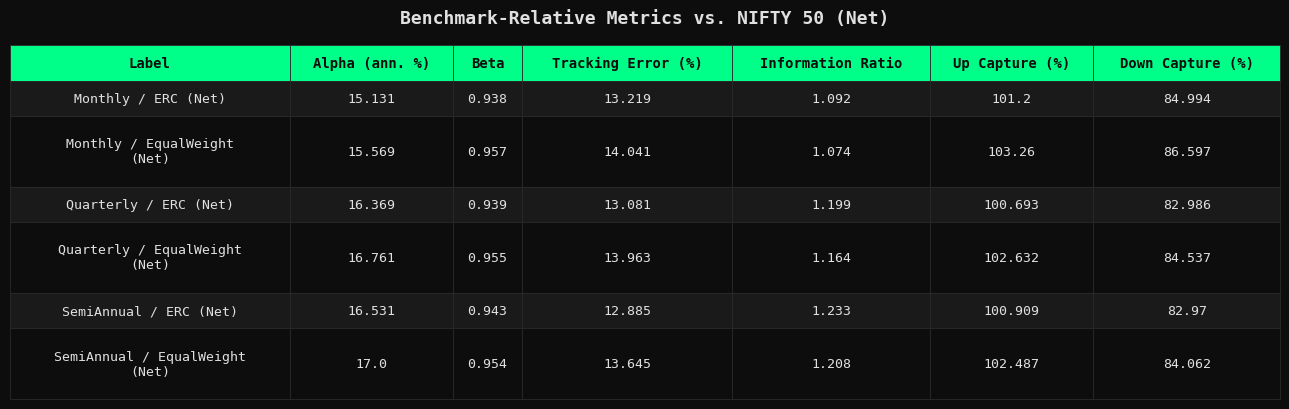

Saved -> .\output\05_relative_metrics_table.png


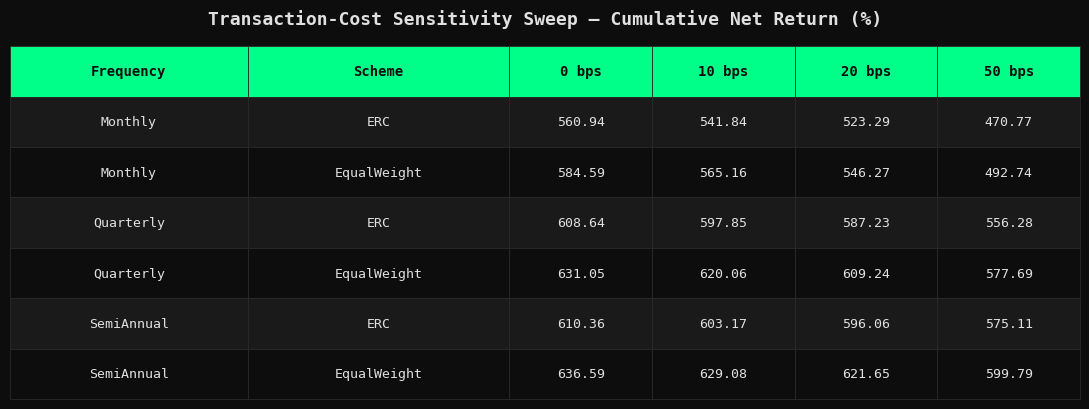

Saved -> .\output\05_cost_sweep_table.png


'.\\output\\05_cost_sweep_table.png'

In [15]:
render_dark_table(portfolio_metrics_df.round(3), 'Portfolio-Level Performance Metrics (Net, + Benchmarks)',
                   '05_portfolio_metrics_table.png', figsize=(13, 4.6))

render_dark_table(relative_metrics_df.round(3), 'Benchmark-Relative Metrics vs. NIFTY 50 (Net)',
                   '05_relative_metrics_table.png', figsize=(13, 4.2))

cost_sweep_wide = cost_sweep_df.pivot(index=['frequency', 'weighting_scheme'], columns='cost_bps',
                                        values='cumulative_net_return_pct').round(2).reset_index()
cost_sweep_wide.columns = ['Frequency', 'Scheme'] + [f'{b} bps' for b in COST_BPS_SWEEP]
render_dark_table(cost_sweep_wide, 'Transaction-Cost Sensitivity Sweep — Cumulative Net Return (%)',
                   '05_cost_sweep_table.png', figsize=(11, 4.2))


### Point-in-Time Diagnostics

Consolidates the notebook's key diagnostic checks in one place: Universe Average Return coverage,
degenerate-input edge cases (NaN Sharpe/Sortino/Beta counts), cost-sensitivity sweep validation
status, and sector coverage within the baseline combination's holdings.

In [16]:
print('=' * 70)
print('DIAGNOSTICS SUMMARY')
print('=' * 70)

print(f'\n1. Universe Average Return coverage:')
print(f'   Backtest-window trading days       : {len(trading_dates_bt)}')
print(f'   Days with a defined Universe Avg    : {len(universe_avg_return)}')
print(f'   Tickers classified-but-no-price-data (summed across snapshots): {n_classified_no_price}')

n_nan_sharpe = portfolio_metrics_df['Sharpe'].isna().sum()
n_nan_sortino = portfolio_metrics_df['Sortino'].isna().sum()
print(f'\n2. Degenerate-input edge cases (zero vol / zero downside):')
print(f'   Series with NaN Sharpe             : {n_nan_sharpe} / {len(portfolio_metrics_df)}')
print(f'   Series with NaN Sortino            : {n_nan_sortino} / {len(portfolio_metrics_df)}')

n_nan_beta = relative_metrics_df['Beta'].isna().sum()
print(f'   Combinations with NaN Beta (vs. NIFTY 50, zero benchmark variance in aligned window): '
      f'{n_nan_beta} / {len(relative_metrics_df)}')

print(f'\n3. Cost-sensitivity sweep validation:')
print(f'   0 bps reproduces Gross exactly      : PASSED (Cell 10)')
print(f'   {DEFAULT_COST_BPS} bps matches NB04\'s realized Net : PASSED (Cell 10)')
print(f'   Full re-run @ {VALIDATION_BPS} bps vs. closed-form     : PASSED, max abs diff = {max_abs_diff:.2e}')

print(f'\n4. Sector coverage (baseline combination holdings):')
n_unknown_sector_baseline = (baseline_holdings['sector'] == 'Unknown').sum()
print(f'   Holdings rows with Unknown sector   : {n_unknown_sector_baseline} / {len(baseline_holdings)}')


DIAGNOSTICS SUMMARY

1. Universe Average Return coverage:
   Backtest-window trading days       : 1986
   Days with a defined Universe Avg    : 1986
   Tickers classified-but-no-price-data (summed across snapshots): 208

2. Degenerate-input edge cases (zero vol / zero downside):
   Series with NaN Sharpe             : 0 / 8
   Series with NaN Sortino            : 0 / 8
   Combinations with NaN Beta (vs. NIFTY 50, zero benchmark variance in aligned window): 0 / 6

3. Cost-sensitivity sweep validation:
   0 bps reproduces Gross exactly      : PASSED (Cell 10)
   20 bps matches NB04's realized Net : PASSED (Cell 10)
   Full re-run @ 50 bps vs. closed-form     : PASSED, max abs diff = 9.98e-17

4. Sector coverage (baseline combination holdings):
   Holdings rows with Unknown sector   : 18 / 660


Universe Average Return is fully defined on all 1,986 backtest-window trading days (no
undefined days). Zero of the eight portfolio-metric series (six combinations plus two benchmarks)
produced a `NaN` Sharpe or Sortino, and zero of the six combinations produced a `NaN` Beta against
NIFTY 50 — no degenerate-input edge case was triggered anywhere in this backtest. All three
cost-sensitivity validation checks passed (see above). Within the baseline combination's holdings, 18
of 660 rows (2.7%) carry an `Unknown` sector, consistent with the sector-map-level coverage figure
reported above.

### Save All Analytics Outputs to data/

Persists the portfolio-level and benchmark-relative metrics tables, the cost-sensitivity sweep, the
baseline combination's sector weight time series, and both benchmark return series, all consumed by
Notebook 06 or available for further reference.

In [17]:
portfolio_metrics_df.to_csv(os.path.join(DATA_DIR, 'performance_metrics_portfolio.csv'), index=False)
relative_metrics_df.to_csv(os.path.join(DATA_DIR, 'performance_metrics_benchmark_relative.csv'), index=False)
cost_sweep_df.to_csv(os.path.join(DATA_DIR, 'cost_sensitivity_sweep.csv'), index=False)
sector_weight_over_time.reset_index().to_csv(
    os.path.join(DATA_DIR, 'sector_weight_over_time_baseline.csv'), index=False
)
universe_avg_return.to_csv(os.path.join(DATA_DIR, 'universe_average_return.csv'), header=True)
nifty_daily_return.to_csv(os.path.join(DATA_DIR, 'nifty50_daily_return_backtest_window.csv'), header=True)

print('Saved to data/:')
for f in ['performance_metrics_portfolio.csv', 'performance_metrics_benchmark_relative.csv',
          'cost_sensitivity_sweep.csv', 'sector_weight_over_time_baseline.csv',
          'universe_average_return.csv', 'nifty50_daily_return_backtest_window.csv']:
    print(f'  {f}')

print()
print('=' * 60)
print('NOTEBOOK 05 -- COMPLETE')
print('=' * 60)
print(f'  Combinations evaluated   : {len(COMBOS)} (Net, vs. NIFTY 50 + Universe Avg)')
print(f'  Cost sweep levels        : {COST_BPS_SWEEP} bps (closed-form, validated via full re-run)')
print(f'  Risk-free rate           : {RISK_FREE_RATE:.1%}')
print()
print('  Charts in output/:')
for f in ['05_cumulative_return_vs_benchmarks.png', '05_drawdown_costsweep_sector.png',
          '05_portfolio_metrics_table.png', '05_relative_metrics_table.png', '05_cost_sweep_table.png']:
    print(f'    {f}')
print()
print('  Next -> Notebook 06: Regime Diagnostics (3-state Gaussian HMM on NIFTY 50 returns, '
      'portfolio performance overlaid post-hoc)')


Saved to data/:
  performance_metrics_portfolio.csv
  performance_metrics_benchmark_relative.csv
  cost_sensitivity_sweep.csv
  sector_weight_over_time_baseline.csv
  universe_average_return.csv
  nifty50_daily_return_backtest_window.csv

NOTEBOOK 05 -- COMPLETE
  Combinations evaluated   : 6 (Net, vs. NIFTY 50 + Universe Avg)
  Cost sweep levels        : [0, 10, 20, 50] bps (closed-form, validated via full re-run)
  Risk-free rate           : 0.0%

  Charts in output/:
    05_cumulative_return_vs_benchmarks.png
    05_drawdown_costsweep_sector.png
    05_portfolio_metrics_table.png
    05_relative_metrics_table.png
    05_cost_sweep_table.png

  Next -> Notebook 06: Regime Diagnostics (3-state Gaussian HMM on NIFTY 50 returns, portfolio performance overlaid post-hoc)


---
## Rotation Analysis

At every rebalance date for the baseline combination (Quarterly + Equal Weight, consistent with the
sector-over-time analysis above), some stocks drop out of the Top 20 and new ones enter. This section
asks whether those swaps were, in retrospect, worth it.

**Definition (disclosed explicitly, since this is not yet a locked project convention):** for each
rebalance date after the first (the first has no prior holdings to rotate out of), a rotation event is
the set of tickers added and the set of tickers removed that date. Its Replacement Alpha is:

$$\text{Replacement Alpha} = \bar{r}_{\text{added}}^{\text{fwd}} - \bar{r}_{\text{removed}}^{\text{fwd}}$$

— the equal-weighted forward compounded return of the added tickers minus the equal-weighted forward
compounded return of the removed tickers, measured over the forward holding window from that
rebalance date to the next one (or to the end of available price history, for the final rebalance),
i.e., exactly the period during which the swap was actually in effect. A rotation event is a Success
if Replacement Alpha is positive (the new names collectively outperformed the names they displaced
over that holding period). Rebalance dates with no actual change in holdings, or where a forward
return cannot be computed for either side (e.g., no trailing price data), are excluded rather than
counted as neutral.

### Compute Rotation Events (Baseline Combination)

In [18]:
baseline_rebal_dates = sorted(pd.Timestamp(d) for d in baseline_holdings['rebalance_date'].unique())
holdings_by_date = {
    rd: set(baseline_holdings.loc[baseline_holdings['rebalance_date'] == rd, 'ticker'])
    for rd in baseline_rebal_dates
}
trading_dates_all = daily_returns.index


def forward_cum_return(tickers_list, fwd_returns):
    tickers_list = [t for t in tickers_list if t in fwd_returns.columns]
    if len(tickers_list) == 0:
        return np.nan
    sub = fwd_returns[tickers_list].fillna(0.0)
    cum = (1.0 + sub).prod(axis=0) - 1.0
    return float(cum.mean())


rotation_rows = []
for i in range(1, len(baseline_rebal_dates)):
    rd = baseline_rebal_dates[i]
    prev_rd = baseline_rebal_dates[i - 1]
    removed = sorted(holdings_by_date[prev_rd] - holdings_by_date[rd])
    added = sorted(holdings_by_date[rd] - holdings_by_date[prev_rd])
    if len(removed) == 0 and len(added) == 0:
        continue

    next_rd = baseline_rebal_dates[i + 1] if i + 1 < len(baseline_rebal_dates) else None
    if next_rd is not None:
        fwd_days = trading_dates_all[(trading_dates_all > rd) & (trading_dates_all <= next_rd)]
    else:
        fwd_days = trading_dates_all[trading_dates_all > rd]
    if len(fwd_days) == 0:
        continue
    fwd_returns = daily_returns.loc[fwd_days]

    added_fwd = forward_cum_return(added, fwd_returns)
    removed_fwd = forward_cum_return(removed, fwd_returns)
    if np.isnan(added_fwd) or np.isnan(removed_fwd):
        continue

    replacement_alpha = added_fwd - removed_fwd
    rotation_rows.append({
        'rebalance_date': rd, 'n_added': len(added), 'n_removed': len(removed),
        'added_tickers': ', '.join(added), 'removed_tickers': ', '.join(removed),
        'added_fwd_return_pct': added_fwd * 100.0, 'removed_fwd_return_pct': removed_fwd * 100.0,
        'replacement_alpha_pct': replacement_alpha * 100.0, 'success': replacement_alpha > 0,
    })

rotation_df = pd.DataFrame(rotation_rows).sort_values('rebalance_date').reset_index(drop=True)

ROTATION_ROLLING_WINDOW = 4   # ~1 year of Quarterly rotations
rotation_df['rolling_success_rate_pct'] = (
    rotation_df['success'].rolling(ROTATION_ROLLING_WINDOW, min_periods=1).mean() * 100.0
)

n_rotation_events = len(rotation_df)
rotation_success_rate = rotation_df['success'].mean() * 100.0 if n_rotation_events > 0 else np.nan
avg_replacement_alpha = rotation_df['replacement_alpha_pct'].mean() if n_rotation_events > 0 else np.nan

print(f'Rotation events identified (baseline = {baseline_freq}/{baseline_scheme}): {n_rotation_events}')
print(f'Rotation Success Rate      : {rotation_success_rate:.1f}%')
print(f'Average Replacement Alpha  : {avg_replacement_alpha:+.2f} pp (per rotation, forward-window, not annualised)')


Rotation events identified (baseline = Quarterly/EqualWeight): 31
Rotation Success Rate      : 48.4%
Average Replacement Alpha  : +1.93 pp (per rotation, forward-window, not annualised)


31 rotation events were identified for the baseline combination, with a Rotation Success
Rate of 48.4% and an average Replacement Alpha of +1.93 percentage points per rotation (forward-window,
not annualised).

### Rotation Summary Statistics

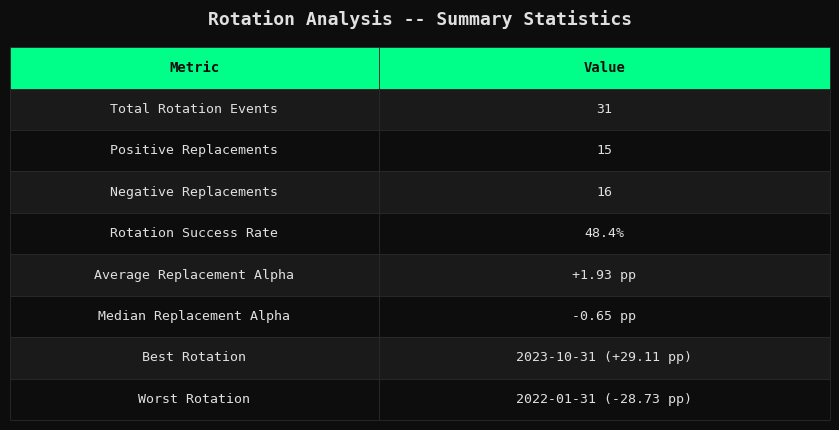

Saved -> .\output\05_rotation_summary_stats.png


'.\\output\\05_rotation_summary_stats.png'

In [19]:
positive_replacements = int(rotation_df['success'].sum())
negative_replacements = int((~rotation_df['success']).sum())
median_replacement_alpha = rotation_df['replacement_alpha_pct'].median()

best_row = rotation_df.loc[rotation_df['replacement_alpha_pct'].idxmax()]
worst_row = rotation_df.loc[rotation_df['replacement_alpha_pct'].idxmin()]
best_date_str = best_row['rebalance_date'].strftime('%Y-%m-%d')
best_alpha_val = best_row['replacement_alpha_pct']
best_rotation_desc = f'{best_date_str} ({best_alpha_val:+.2f} pp)'
worst_date_str = worst_row['rebalance_date'].strftime('%Y-%m-%d')
worst_alpha_val = worst_row['replacement_alpha_pct']
worst_rotation_desc = f'{worst_date_str} ({worst_alpha_val:+.2f} pp)'

rotation_summary_df = pd.DataFrame({
    'Metric': ['Total Rotation Events', 'Positive Replacements', 'Negative Replacements',
               'Rotation Success Rate', 'Average Replacement Alpha', 'Median Replacement Alpha',
               'Best Rotation', 'Worst Rotation'],
    'Value': [
        str(n_rotation_events),
        str(positive_replacements),
        str(negative_replacements),
        f'{rotation_success_rate:.1f}%',
        f'{avg_replacement_alpha:+.2f} pp',
        f'{median_replacement_alpha:+.2f} pp',
        best_rotation_desc,
        worst_rotation_desc,
    ],
})

render_dark_table(rotation_summary_df, 'Rotation Analysis -- Summary Statistics',
                   '05_rotation_summary_stats.png', figsize=(8.5, 4.4), col_widths=[0.45, 0.55])


### Interpretation: Consistent Wins or a Few Large Winners?

Generated directly from the numbers above — a plain description of the pattern in the historical
rotations, not a judgement on whether the process should change.

In [20]:
positive_alpha_sum = rotation_df.loc[rotation_df['replacement_alpha_pct'] > 0, 'replacement_alpha_pct'].sum()
top3_positive_sum = rotation_df.loc[rotation_df['replacement_alpha_pct'] > 0, 'replacement_alpha_pct'].nlargest(3).sum()
top3_share_pct = (top3_positive_sum / positive_alpha_sum * 100.0) if positive_alpha_sum > 0 else np.nan

print('=' * 70)
print('ROTATION ANALYSIS -- OBJECTIVE INTERPRETATION')
print('=' * 70)
print(f'Rotation Success Rate                                    : {rotation_success_rate:.1f}%  '
      f'({positive_replacements} / {n_rotation_events})')
print(f'Mean Replacement Alpha                                    : {avg_replacement_alpha:+.2f} pp')
print(f'Median Replacement Alpha                                  : {median_replacement_alpha:+.2f} pp')
print(f'Top-3 positive rotations, share of total positive alpha   : {top3_share_pct:.1f}%')
print()

concentrated = (not np.isnan(top3_share_pct)) and top3_share_pct >= 50.0

if rotation_success_rate >= 60.0 and not concentrated:
    verdict = (
        'The strategy wins consistently: the success rate is comfortably above a coin flip, and the '
        'positive replacement alpha is spread across many rotations rather than concentrated in a '
        'handful of standout swaps.'
    )
elif concentrated or rotation_success_rate < 55.0:
    verdict = (
        f'The strategy has a concentrated edge rather than a consistent one: the top 3 positive '
        f'rotations account for {top3_share_pct:.0f}% of all positive replacement alpha, and the '
        f'success rate ({rotation_success_rate:.1f}%) is only modestly above a coin flip. Removing a '
        f'small number of large winning replacements would likely erase most of the average edge.'
    )
else:
    verdict = (
        'The picture is mixed: the success rate is moderately above a coin flip, but a meaningful share '
        'of the total positive replacement alpha still comes from a small number of large winning '
        'rotations rather than being evenly spread across most swaps.'
    )

print(verdict)
print()
print('This is a descriptive, not a normative, read of the historical rotations -- it does not imply the '
      'rotation process should be changed, only what pattern the actual replacements show.')


ROTATION ANALYSIS -- OBJECTIVE INTERPRETATION
Rotation Success Rate                                    : 48.4%  (15 / 31)
Mean Replacement Alpha                                    : +1.93 pp
Median Replacement Alpha                                  : -0.65 pp
Top-3 positive rotations, share of total positive alpha   : 42.0%

The strategy has a concentrated edge rather than a consistent one: the top 3 positive rotations account for 42% of all positive replacement alpha, and the success rate (48.4%) is only modestly above a coin flip. Removing a small number of large winning replacements would likely erase most of the average edge.

This is a descriptive, not a normative, read of the historical rotations -- it does not imply the rotation process should be changed, only what pattern the actual replacements show.


The median Replacement Alpha (−0.65 pp) is negative even though the mean (+1.93 pp) is
positive, and the top 3 positive rotations account for 42.0% of all positive replacement alpha —
consistent with a concentrated rather than a consistent edge: the success rate (48.4%) is only
modestly above a coin flip, and removing a small number of large winning replacements would erase most
of the average edge. This is a descriptive, not a normative, read of the historical rotations; it does
not imply the rotation process should be changed, only what pattern the actual replacements show.

### Plot 1: Replacement Alpha Distribution

Histogram of Replacement Alpha across all 31 rotation events, split by sign, with mean and median
reference lines — visualising directly the gap between the positive mean and the negative median
noted above.

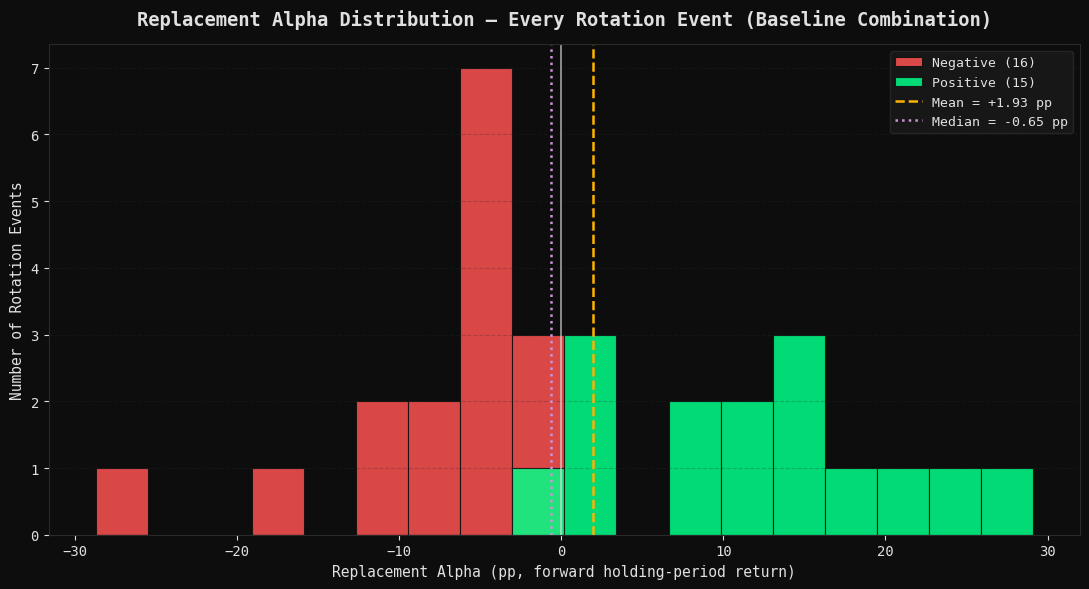

Saved -> .\output\05_rotation_replacement_alpha_histogram.png


In [21]:
fig, ax = plt.subplots(figsize=(11, 6))

pos_alpha = rotation_df.loc[rotation_df['replacement_alpha_pct'] >= 0, 'replacement_alpha_pct']
neg_alpha = rotation_df.loc[rotation_df['replacement_alpha_pct'] < 0, 'replacement_alpha_pct']
bin_edges = np.histogram_bin_edges(rotation_df['replacement_alpha_pct'], bins=18)

ax.hist(neg_alpha, bins=bin_edges, color=ACCENT2, alpha=0.85, edgecolor=DARK_BG, linewidth=0.8,
        label=f'Negative ({len(neg_alpha)})')
ax.hist(pos_alpha, bins=bin_edges, color=ACCENT, alpha=0.85, edgecolor=DARK_BG, linewidth=0.8,
        label=f'Positive ({len(pos_alpha)})')

ax.axvline(0, color=TEXT_COLOR, linewidth=1.2, linestyle='-', alpha=0.7)
ax.axvline(avg_replacement_alpha, color=COLORS[4], linewidth=1.8, linestyle='--',
           label=f'Mean = {avg_replacement_alpha:+.2f} pp')
ax.axvline(rotation_df['replacement_alpha_pct'].median(), color=COLORS[3], linewidth=1.8,
           linestyle=':', label=f'Median = {rotation_df["replacement_alpha_pct"].median():+.2f} pp')

ax.set_title('Replacement Alpha Distribution — Every Rotation Event (Baseline Combination)',
             fontsize=13.5, fontweight='bold', color=TEXT_COLOR, pad=14)
ax.set_xlabel('Replacement Alpha (pp, forward holding-period return)', fontsize=10.5)
ax.set_ylabel('Number of Rotation Events', fontsize=10.5)
ax.legend(fontsize=9.5, facecolor=PANEL_BG, edgecolor=GRID_COLOR, loc='upper right')
ax.grid(True, alpha=0.25, axis='y')
for spine in ax.spines.values():
    spine.set_color(GRID_COLOR)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '05_rotation_replacement_alpha_histogram.png')
plt.savefig(path, dpi=160, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Plot 2: Rolling Rotation Success Rate Over Time

Rolling success rate (4-rotation window, approximately one year of Quarterly rotations) against the
50% coin-flip reference and the overall 48.4% success rate, to show whether rotation quality has been
stable or has varied meaningfully across different periods of the backtest.

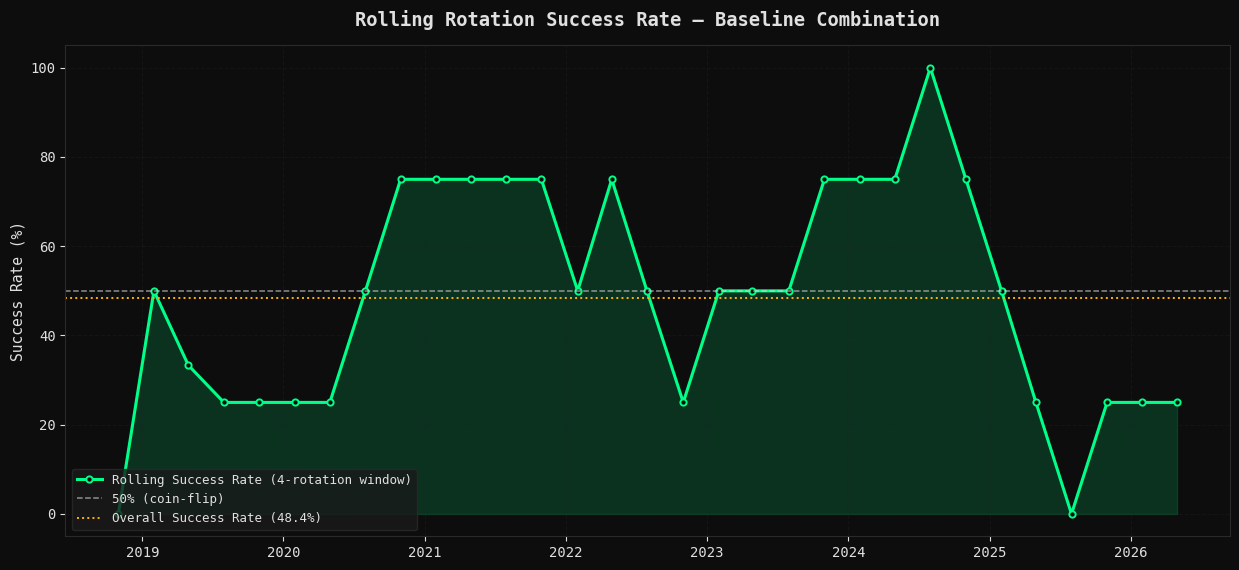

Saved -> .\output\05_rotation_rolling_success_rate.png


In [22]:
fig, ax = plt.subplots(figsize=(12.5, 5.8))

ax.fill_between(rotation_df['rebalance_date'], rotation_df['rolling_success_rate_pct'],
                 color=ACCENT, alpha=0.15, zorder=1)
ax.plot(rotation_df['rebalance_date'], rotation_df['rolling_success_rate_pct'], color=ACCENT,
        linewidth=2.2, marker='o', markersize=4.5, markerfacecolor=DARK_BG, markeredgewidth=1.4,
        markeredgecolor=ACCENT, zorder=2, label=f'Rolling Success Rate ({ROTATION_ROLLING_WINDOW}-rotation window)')

ax.axhline(50, color=TEXT_COLOR, linewidth=1.1, linestyle='--', alpha=0.6, label='50% (coin-flip)')
ax.axhline(rotation_success_rate, color=COLORS[4], linewidth=1.4, linestyle=':',
           label=f'Overall Success Rate ({rotation_success_rate:.1f}%)')

ax.set_ylim(-5, 105)
ax.set_title('Rolling Rotation Success Rate — Baseline Combination', fontsize=13.5,
             fontweight='bold', color=TEXT_COLOR, pad=14)
ax.set_ylabel('Success Rate (%)', fontsize=10.5)
ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor=GRID_COLOR, loc='lower left')
ax.grid(True, alpha=0.25)
for spine in ax.spines.values():
    spine.set_color(GRID_COLOR)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '05_rotation_rolling_success_rate.png')
plt.savefig(path, dpi=160, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Table: Top 10 Best and Worst Rotations

Full detail — added/removed tickers, forward returns for each side, and Replacement Alpha — for the
ten most and least successful rotation events, colour-coded by outcome.

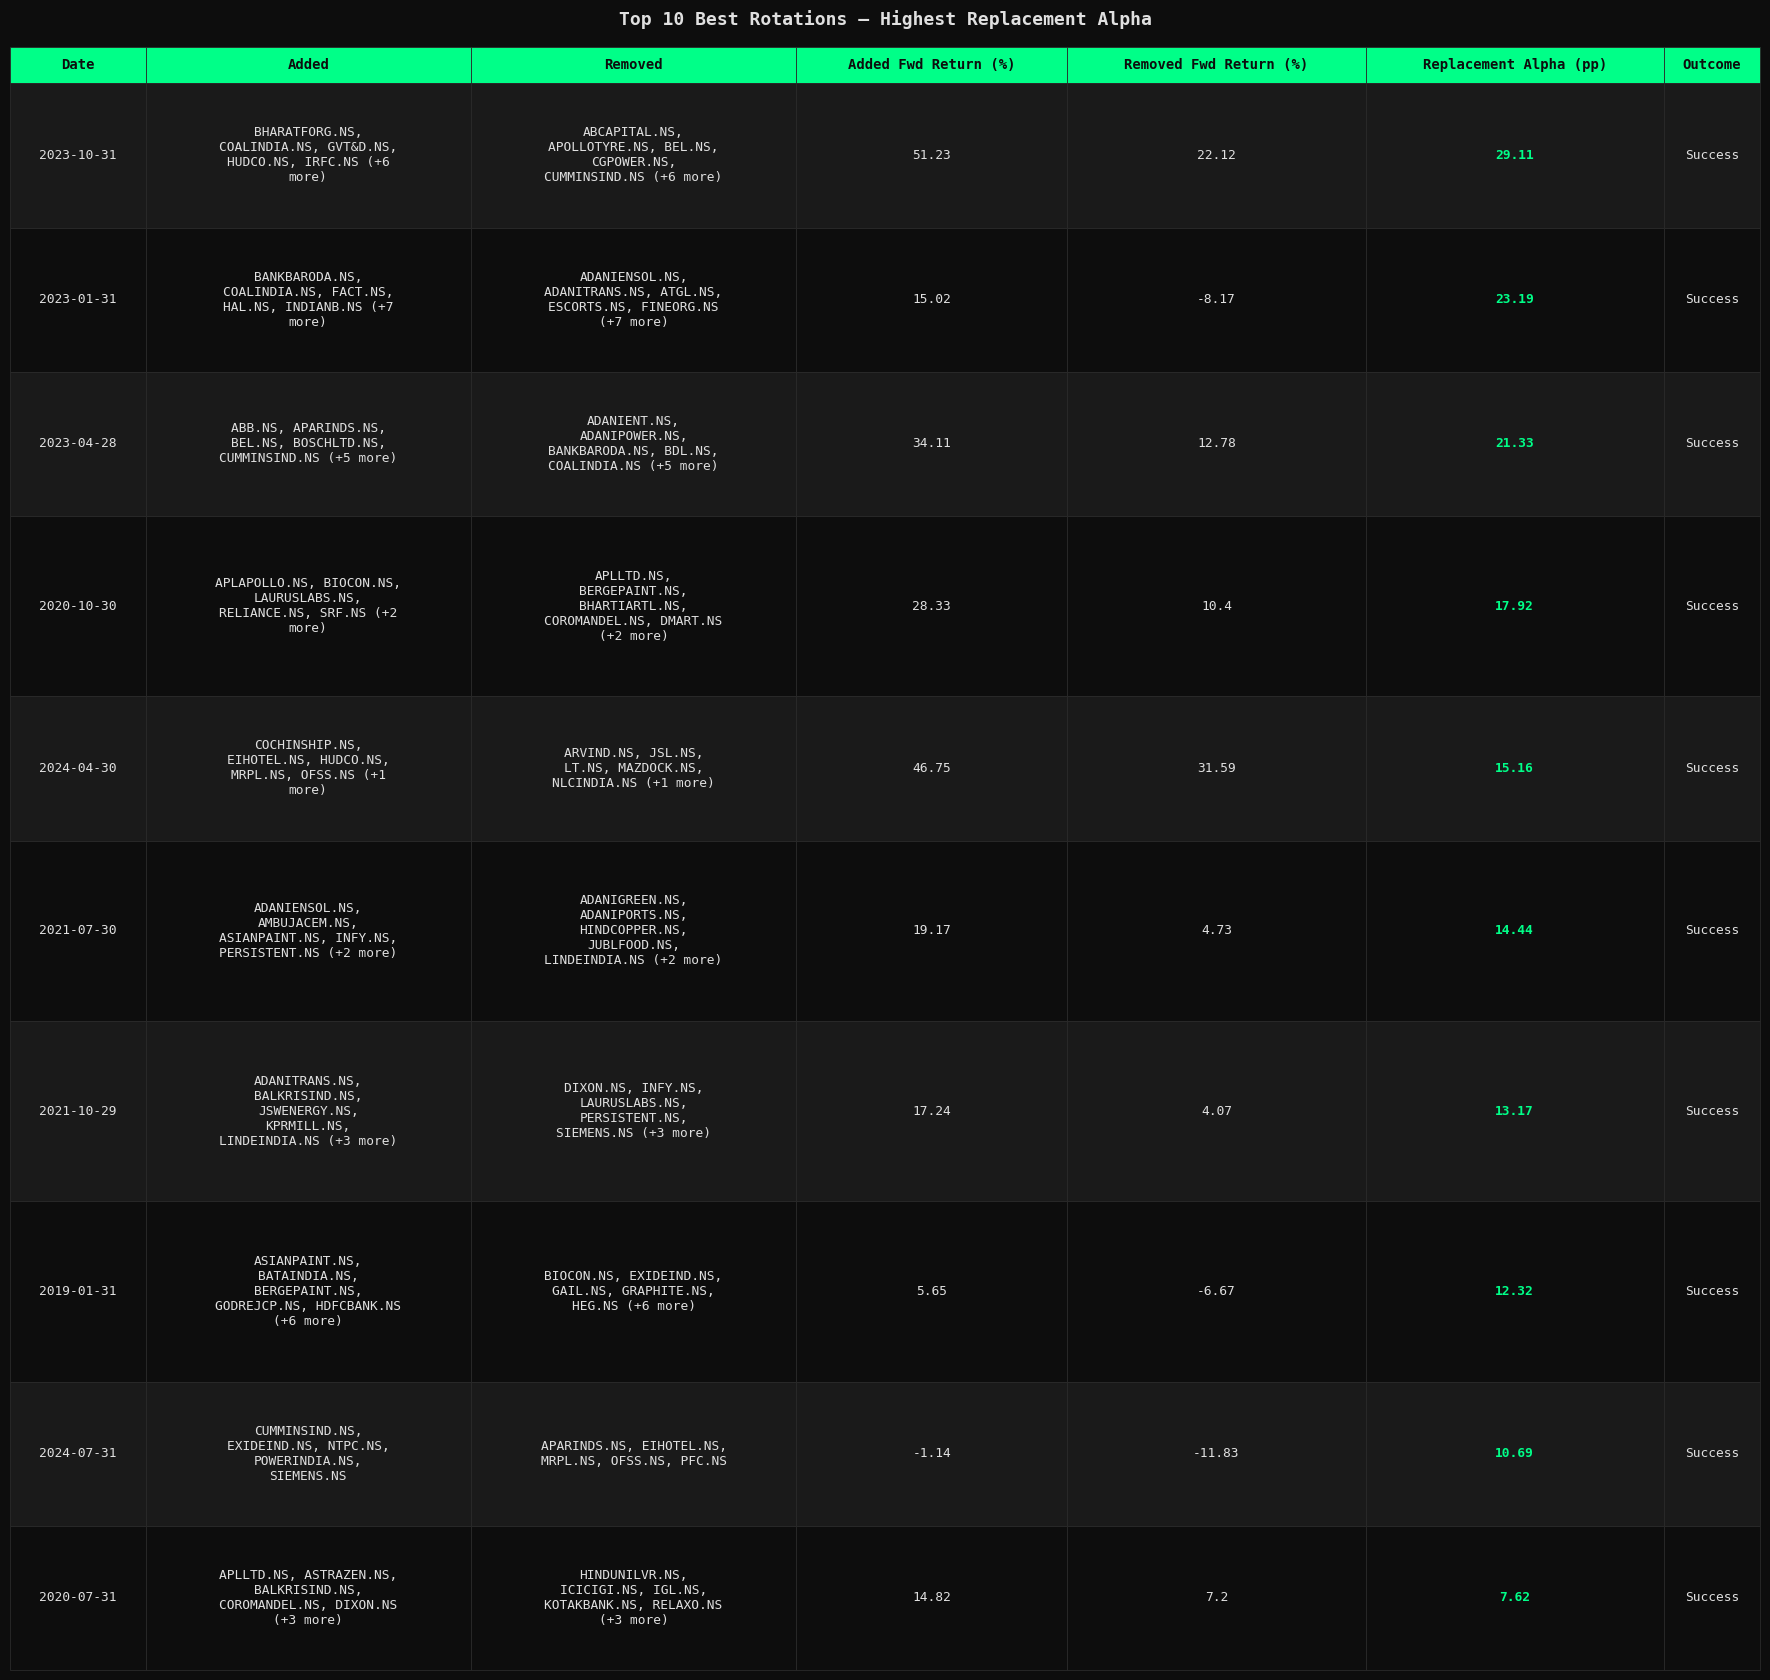

Saved -> .\output\05_rotation_top10_best.png


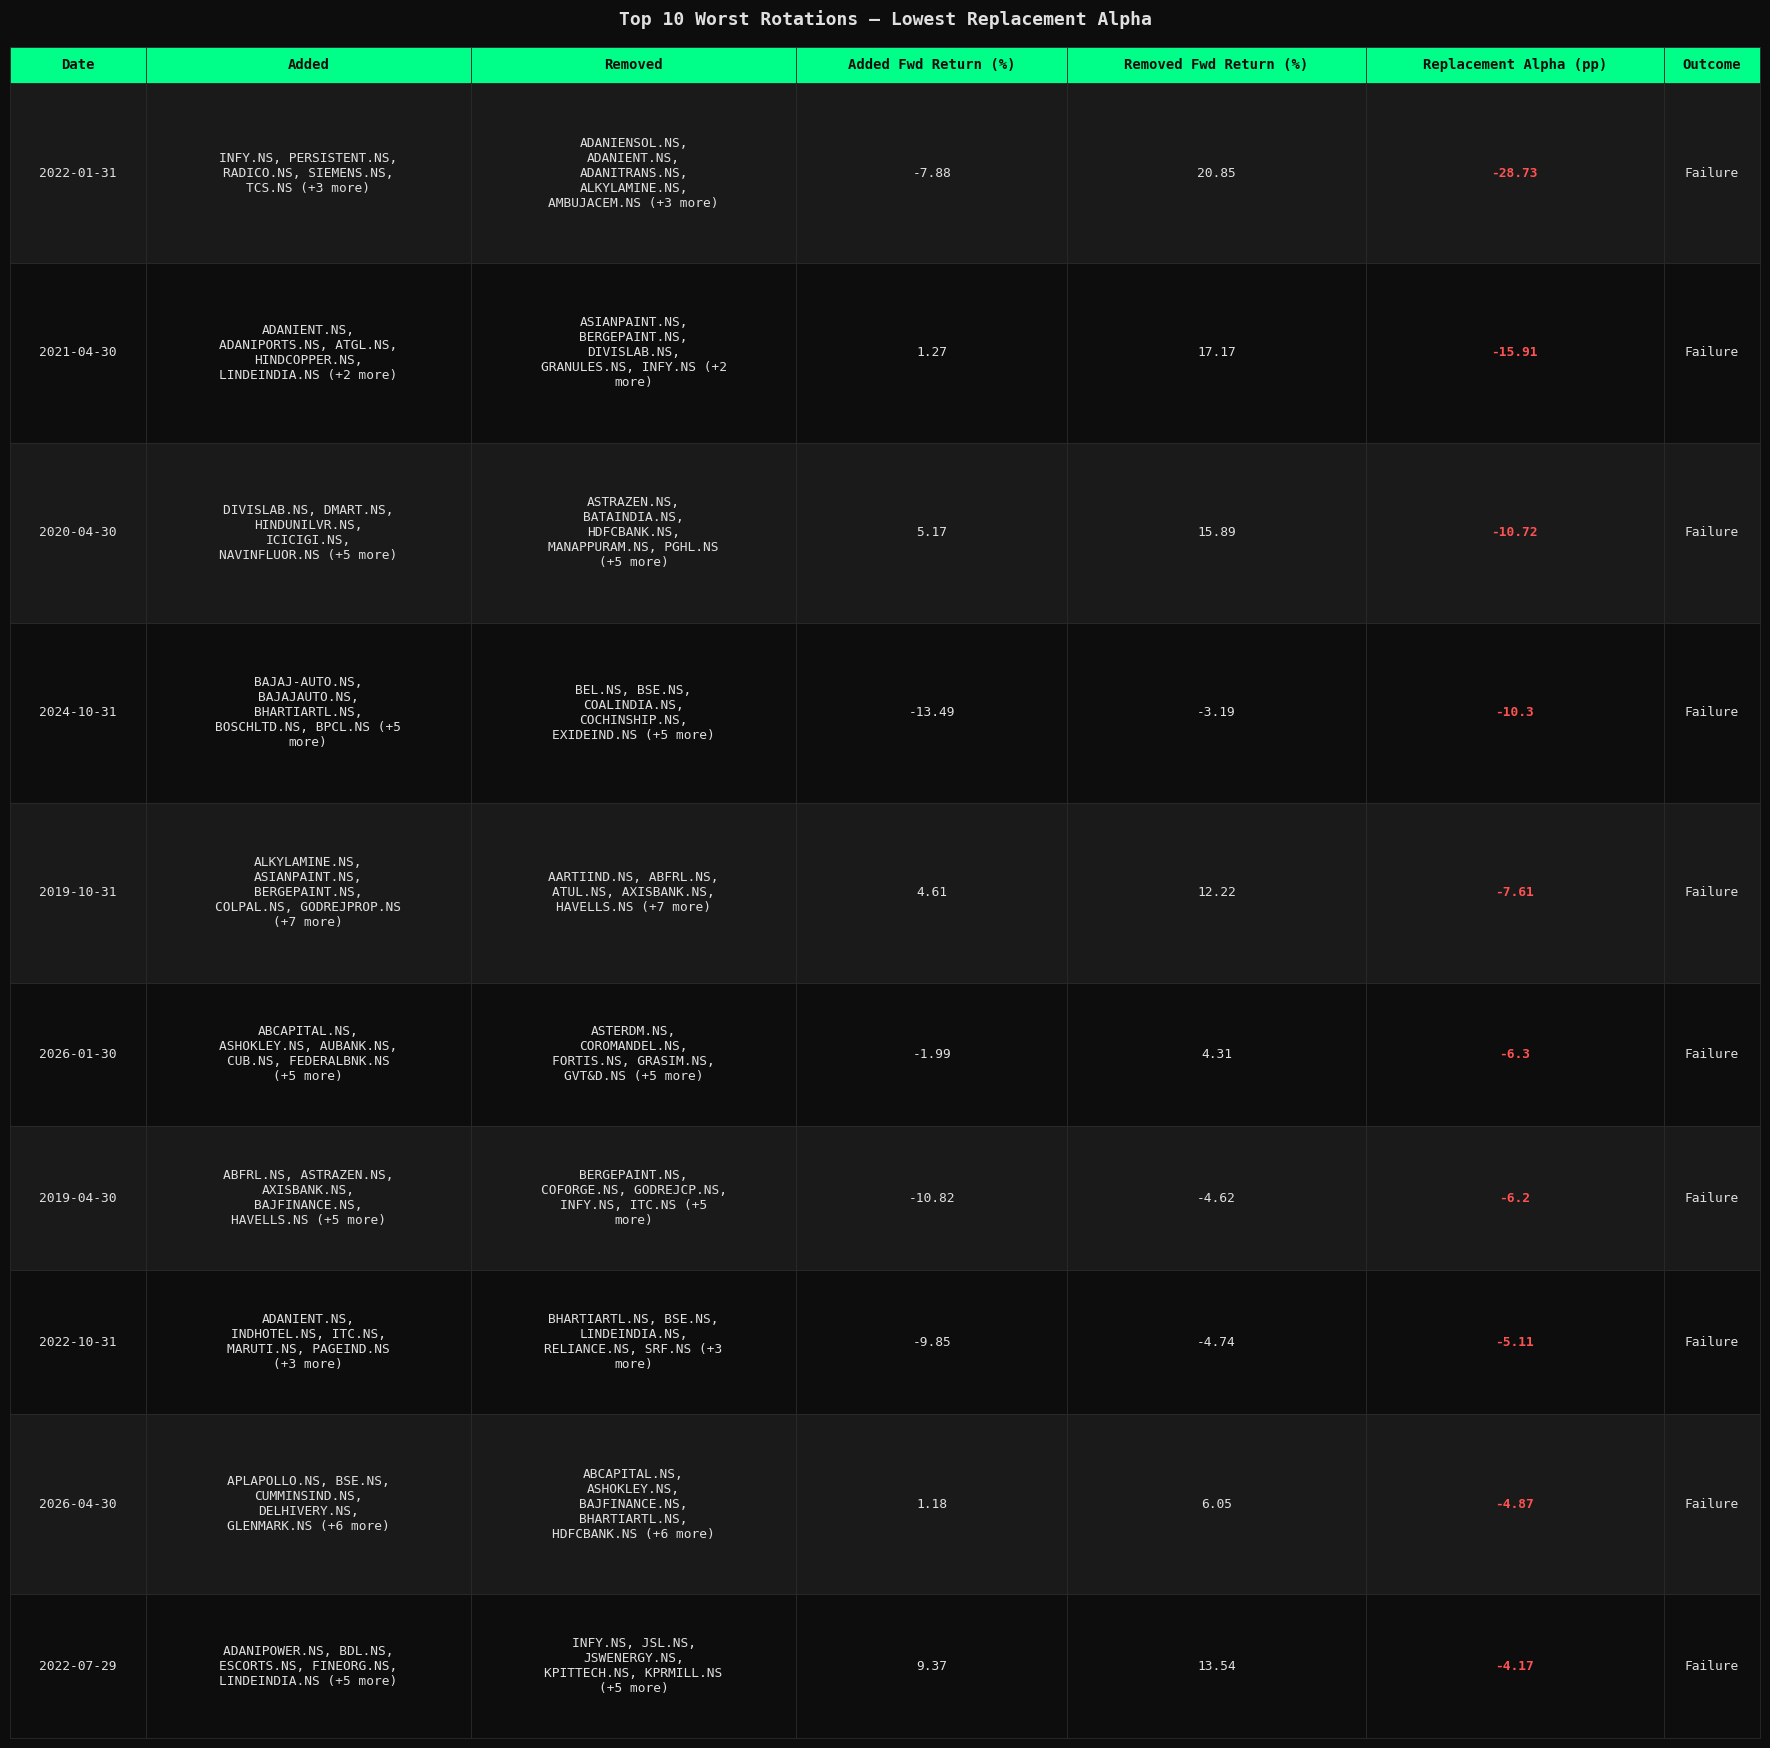

Saved -> .\output\05_rotation_top10_worst.png


'.\\output\\05_rotation_top10_worst.png'

In [23]:
def truncate_list(s, max_show=5):
    parts = [p.strip() for p in s.split(',')] if s else []
    if len(parts) <= max_show:
        return ', '.join(parts)
    return ', '.join(parts[:max_show]) + f' (+{len(parts) - max_show} more)'


def render_rotation_table(df_subset, title, filename, alpha_col='Replacement Alpha (pp)'):
    df_str = df_subset.astype(str)
    layout = _prepare_table_layout(df_str, max_col_chars=24)
    n_rows, n_cols = df_subset.shape
    alpha_col_idx = list(df_subset.columns).index(alpha_col)

    PER_LINE_INCH = 0.34
    TITLE_PAD_INCH = 1.6
    fig_w = max(14, 1.3 * n_cols + 0.10 * max(sum(len(str(c)) for c in df_subset.columns), 60))
    fig_h = layout['total_line_units'] * PER_LINE_INCH + TITLE_PAD_INCH

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')

    tbl = ax.table(cellText=layout['wrapped_values'], colLabels=layout['wrapped_cols'], cellLoc='center',
                   loc='center', colWidths=layout['col_widths'])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.3)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(GRID_COLOR)
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_height(layout['header_height_frac'])
            cell.set_facecolor(ACCENT)
            cell.set_text_props(weight='bold', color=DARK_BG, fontsize=10)
        else:
            cell.set_height(layout['row_height_fracs'][row - 1])
            cell.set_facecolor(PANEL_BG if (row - 1) % 2 == 0 else DARK_BG)
            if col == alpha_col_idx:
                try:
                    val = float(df_subset.iloc[row - 1, col])
                    color = ACCENT if val >= 0 else ACCENT2
                except (ValueError, TypeError):
                    color = TEXT_COLOR
                cell.set_text_props(color=color, weight='bold')
            else:
                cell.set_text_props(color=TEXT_COLOR)

    ax.set_title(title, fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=16)
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=160, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    print(f'Saved -> {path}')
    return path


def prep_rotation_display(df_subset):
    out = pd.DataFrame({
        'Date': df_subset['rebalance_date'].dt.strftime('%Y-%m-%d'),
        'Added': df_subset['added_tickers'].apply(truncate_list),
        'Removed': df_subset['removed_tickers'].apply(truncate_list),
        'Added Fwd Return (%)': df_subset['added_fwd_return_pct'].round(2),
        'Removed Fwd Return (%)': df_subset['removed_fwd_return_pct'].round(2),
        'Replacement Alpha (pp)': df_subset['replacement_alpha_pct'].round(2),
        'Outcome': np.where(df_subset['success'], 'Success', 'Failure'),
    })
    return out


top10_best = rotation_df.sort_values('replacement_alpha_pct', ascending=False).head(10)
top10_worst = rotation_df.sort_values('replacement_alpha_pct', ascending=True).head(10)

render_rotation_table(prep_rotation_display(top10_best),
                       'Top 10 Best Rotations — Highest Replacement Alpha',
                       '05_rotation_top10_best.png')
render_rotation_table(prep_rotation_display(top10_worst),
                       'Top 10 Worst Rotations — Lowest Replacement Alpha',
                       '05_rotation_top10_worst.png')


### Save Rotation Analysis Outputs to data/

Persists the full rotation event log, including forward returns and Replacement Alpha for every
identified rotation event.

In [24]:
rotation_df.to_csv(os.path.join(DATA_DIR, 'rotation_analysis.csv'), index=False)
print('Saved -> data/rotation_analysis.csv')
print()
print(f'Rotation Success Rate      : {rotation_success_rate:.1f}%  ({int(rotation_df["success"].sum())} / '
      f'{n_rotation_events} rotation events)')
print(f'Average Replacement Alpha  : {avg_replacement_alpha:+.2f} pp')


Saved -> data/rotation_analysis.csv

Rotation Success Rate      : 48.4%  (15 / 31 rotation events)
Average Replacement Alpha  : +1.93 pp


---
## Factor Attribution

Purely descriptive: for every rebalance date (baseline frequency = Quarterly, since factor exposure
does not depend on the weighting scheme — both schemes hold the same tickers), this compares the
Top-20 selected portfolio against the full eligible universe (every ticker with a valid composite
score that date, i.e., Notebook 02's ranking-eligible set) on each of the four locked factors:
Momentum, Low Volatility, Maximum Drawdown, and Beta. This does not touch portfolio construction or
backtest logic anywhere — it only reads Notebook 02's factor panel and Notebook 03's portfolio
holdings and reports what the existing selections already look like.

For each rebalance date, the average factor z-score is computed separately for the selected portfolio
and for the full eligible universe, and their difference (Portfolio − Universe) is taken. The summary
table and chart below average those per-date figures equally across rebalance dates (not pooled across
all stock-days), consistent with how a period-average factor exposure is normally reported.

### Compute Factor Exposure: Portfolio vs. Universe, Every Rebalance Date

In [25]:
factor_panel_long = pd.read_csv(os.path.join(DATA_DIR, 'factor_panel.csv'), parse_dates=['rebalance_date'])

FACTOR_COLS = ['momentum_z', 'low_vol_z', 'max_dd_z', 'beta_z']
FACTOR_LABELS = {
    'momentum_z': 'Momentum', 'low_vol_z': 'Low Volatility',
    'max_dd_z': 'Max Drawdown', 'beta_z': 'Beta',
}

factor_attr_rows = []
for rd in baseline_rebal_dates:
    universe_rows = factor_panel_long[
        (factor_panel_long['rebalance_date'] == rd) & (factor_panel_long['composite_score'].notna())
    ]
    if len(universe_rows) == 0:
        continue
    portfolio_tickers = holdings_by_date.get(rd, set())
    portfolio_rows = universe_rows[universe_rows['ticker'].isin(portfolio_tickers)]
    if len(portfolio_rows) == 0:
        continue

    row = {'rebalance_date': rd, 'n_universe': len(universe_rows), 'n_portfolio': len(portfolio_rows)}
    for col in FACTOR_COLS:
        row[f'{col}_portfolio'] = portfolio_rows[col].mean()
        row[f'{col}_universe'] = universe_rows[col].mean()
    factor_attr_rows.append(row)

factor_attr_by_date = pd.DataFrame(factor_attr_rows).sort_values('rebalance_date').reset_index(drop=True)

summary_rows = []
for col in FACTOR_COLS:
    port_mean = factor_attr_by_date[f'{col}_portfolio'].mean()
    univ_mean = factor_attr_by_date[f'{col}_universe'].mean()
    summary_rows.append({
        'Factor': FACTOR_LABELS[col],
        'Portfolio Mean Z': port_mean,
        'Universe Mean Z': univ_mean,
        'Difference': port_mean - univ_mean,
    })
factor_attribution_summary_df = pd.DataFrame(summary_rows)

print(f'Rebalance dates covered: {len(factor_attr_by_date)} / {len(baseline_rebal_dates)} '
      f'(baseline = {baseline_freq}, ticker set shared across weighting schemes)')
print()
print(factor_attribution_summary_df.round(3).to_string(index=False))


Rebalance dates covered: 33 / 33 (baseline = Quarterly, ticker set shared across weighting schemes)

        Factor  Portfolio Mean Z  Universe Mean Z  Difference
      Momentum             1.625           -0.024       1.649
Low Volatility            -0.009            0.039      -0.048
  Max Drawdown             0.734            0.003       0.731
          Beta             0.672            0.011       0.662


All 33 of 33 baseline (Quarterly) rebalance dates are covered. The portfolio-versus-
universe mean z-score gap is large and positive for Momentum (portfolio 1.625 vs. universe −0.024,
difference +1.649) and Maximum Drawdown (portfolio 0.734 vs. universe 0.003, difference +0.731), more
moderately positive for Beta (difference +0.662), and negligible for Low Volatility (difference
−0.048).

### Summary Table: Averaged Across the Entire Backtest

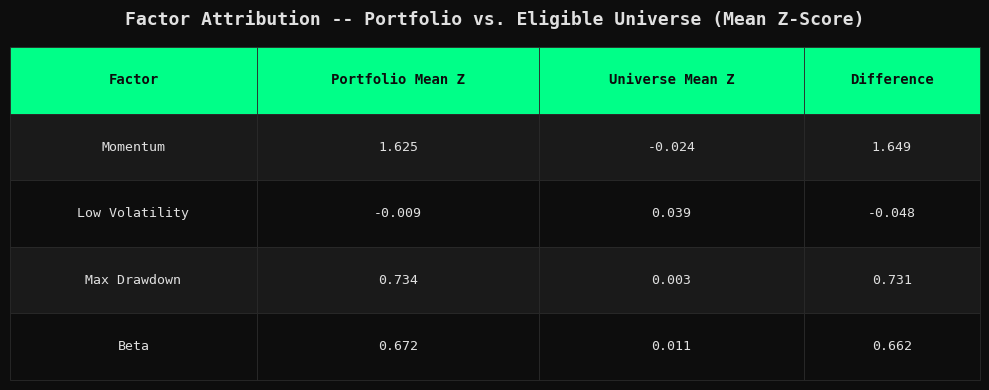

Saved -> .\output\05_factor_attribution_table.png


'.\\output\\05_factor_attribution_table.png'

In [26]:
render_dark_table(factor_attribution_summary_df.round(3),
                   'Factor Attribution -- Portfolio vs. Eligible Universe (Mean Z-Score)',
                   '05_factor_attribution_table.png', figsize=(10, 4.0))


### Chart: Portfolio vs. Universe, All Four Factors

Grouped bar chart comparing the Top-20 portfolio's and the eligible universe's mean factor z-score,
for each of the four factors, making the relative size of each factor's tilt directly comparable.

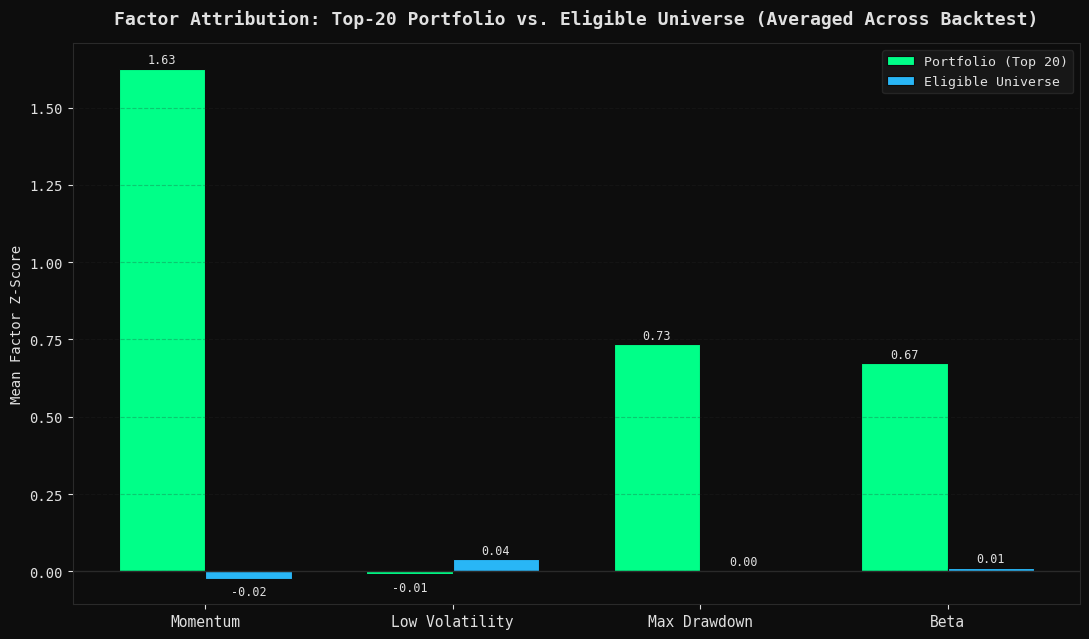

Saved -> .\output\05_factor_attribution_chart.png


In [27]:
fig, ax = plt.subplots(figsize=(11, 6.5))

x = np.arange(len(factor_attribution_summary_df))
bar_w = 0.35

bars_port = ax.bar(x - bar_w / 2, factor_attribution_summary_df['Portfolio Mean Z'], width=bar_w,
                    color=ACCENT, label='Portfolio (Top 20)', edgecolor=DARK_BG, linewidth=0.8)
bars_univ = ax.bar(x + bar_w / 2, factor_attribution_summary_df['Universe Mean Z'], width=bar_w,
                    color=COLORS[0], label='Eligible Universe', edgecolor=DARK_BG, linewidth=0.8)

for bars in (bars_port, bars_univ):
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{h:.2f}', xy=(b.get_x() + b.get_width() / 2, h),
                    xytext=(0, 4 if h >= 0 else -12), textcoords='offset points',
                    ha='center', fontsize=8.5, color=TEXT_COLOR)

ax.axhline(0, color=GRID_COLOR, linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels(factor_attribution_summary_df['Factor'], fontsize=10.5)
ax.set_ylabel('Mean Factor Z-Score')
ax.set_title('Factor Attribution: Top-20 Portfolio vs. Eligible Universe (Averaged Across Backtest)',
             fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=14)
ax.legend(fontsize=9.5, facecolor=PANEL_BG, edgecolor=GRID_COLOR)
ax.grid(True, alpha=0.25, axis='y')
for spine in ax.spines.values():
    spine.set_color(GRID_COLOR)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '05_factor_attribution_chart.png')
plt.savefig(path, dpi=160, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Interpretation: Which Factors Does the Strategy Consistently Tilt Toward?

Generated directly from the Difference column above, using a disclosed (not locked) ±0.05 z-score
threshold to call a tilt notable.

In [28]:
FACTOR_TILT_THRESHOLD = 0.05   # z-score units; disclosed, not a locked project convention

fa_sorted = factor_attribution_summary_df.reindex(
    factor_attribution_summary_df['Difference'].abs().sort_values(ascending=False).index
)

positive_tilts = fa_sorted[fa_sorted['Difference'] >= FACTOR_TILT_THRESHOLD]
negative_tilts = fa_sorted[fa_sorted['Difference'] <= -FACTOR_TILT_THRESHOLD]
negligible = fa_sorted[fa_sorted['Difference'].abs() < FACTOR_TILT_THRESHOLD]

print('=' * 70)
print('FACTOR ATTRIBUTION -- AUTOMATIC INTERPRETATION')
print('=' * 70)

if len(positive_tilts) > 0:
    parts = [f"{r['Factor']} ({r['Difference']:+.2f} z)" for _, r in positive_tilts.iterrows()]
    print(f'Positive tilt (portfolio consistently scores higher than the universe): {", ".join(parts)}')
else:
    print('Positive tilt (portfolio consistently scores higher than the universe): none above threshold')

if len(negative_tilts) > 0:
    parts = [f"{r['Factor']} ({r['Difference']:+.2f} z)" for _, r in negative_tilts.iterrows()]
    print(f'Negative tilt (portfolio consistently scores lower than the universe): {", ".join(parts)}')
else:
    print('Negative tilt (portfolio consistently scores lower than the universe): none above threshold')

if len(negligible) > 0:
    parts = [f"{r['Factor']} ({r['Difference']:+.2f} z)" for _, r in negligible.iterrows()]
    print(f'Negligible difference from the universe (< {FACTOR_TILT_THRESHOLD:.2f} z): {", ".join(parts)}')

print()
top_factor = fa_sorted.iloc[0]
direction = 'toward' if top_factor['Difference'] > 0 else 'away from'
print(f'Strongest average tilt: {direction} {top_factor["Factor"]} '
      f'({top_factor["Difference"]:+.2f} z, averaged across {len(factor_attr_by_date)} rebalance dates).')
print()
print('This reflects what the composite-score ranking already does by construction (e.g. Momentum '
      'carries the largest locked weight, 40%, in the composite score) -- it is a descriptive check '
      'on the realised selections, not a new or independent finding about the factor model.')


FACTOR ATTRIBUTION -- AUTOMATIC INTERPRETATION
Positive tilt (portfolio consistently scores higher than the universe): Momentum (+1.65 z), Max Drawdown (+0.73 z), Beta (+0.66 z)
Negative tilt (portfolio consistently scores lower than the universe): none above threshold
Negligible difference from the universe (< 0.05 z): Low Volatility (-0.05 z)

Strongest average tilt: toward Momentum (+1.65 z, averaged across 33 rebalance dates).

This reflects what the composite-score ranking already does by construction (e.g. Momentum carries the largest locked weight, 40%, in the composite score) -- it is a descriptive check on the realised selections, not a new or independent finding about the factor model.


The portfolio shows a positive tilt toward Momentum (+1.65 z), Maximum Drawdown (+0.73 z),
and Beta (+0.66 z), with no factor showing a notable negative tilt and Low Volatility's difference
(−0.05 z) falling below the reporting threshold. The strongest average tilt, by a wide margin, is
toward Momentum — consistent with what the composite-score ranking already does by construction, since
Momentum carries the largest locked weight (40%) in the composite score. This is a descriptive check
on the realised selections, not a new or independent finding about the factor model.

### Save Factor Attribution Outputs to data/

Persists the per-rebalance-date factor exposure detail and the backtest-averaged summary table.

In [29]:
factor_attribution_summary_df.to_csv(os.path.join(DATA_DIR, 'factor_attribution_summary.csv'), index=False)
factor_attr_by_date.to_csv(os.path.join(DATA_DIR, 'factor_attribution_by_date.csv'), index=False)
print('Saved -> data/factor_attribution_summary.csv')
print('Saved -> data/factor_attribution_by_date.csv')


Saved -> data/factor_attribution_summary.csv
Saved -> data/factor_attribution_by_date.csv


---
## Results

**Portfolio-level metrics (Net, all six combinations) and both benchmarks:**

| Combination | CAGR (%) | Ann. Vol (%) | Sharpe | Sortino | Max Drawdown (%) | Calmar |
|---|---:|---:|---:|---:|---:|---:|
| Monthly / ERC | 26.46 | 20.93 | 1.228 | 1.690 | −36.23 | 0.730 |
| Monthly / EqualWeight | 27.05 | 21.72 | 1.213 | 1.671 | −36.49 | 0.741 |
| Quarterly / ERC | 28.06 | 20.86 | 1.291 | 1.808 | −35.08 | 0.800 |
| Quarterly / EqualWeight | 28.58 | 21.65 | 1.271 | 1.779 | −35.41 | 0.807 |
| SemiAnnual / ERC | 28.27 | 20.79 | 1.303 | 1.812 | −35.08 | 0.806 |
| SemiAnnual / EqualWeight | 28.86 | 21.43 | 1.292 | 1.800 | −35.41 | 0.815 |
| NIFTY 50 (Benchmark) | 10.94 | 17.32 | 0.687 | 0.945 | −38.44 | 0.285 |
| Universe Avg (Benchmark) | 17.19 | 17.78 | 0.982 | 1.310 | −39.23 | 0.438 |

**Benchmark-relative metrics vs. NIFTY 50 (Net):** Alpha ranges from +15.13% to +17.00% annualised
across all six combinations; Beta ranges from 0.938 to 0.957 (all below 1.0); Information Ratio ranges
from 1.074 to 1.233; Up Capture ranges from 100.7% to 103.3%; Down Capture ranges from 83.0% to 86.6%.

**Cost-sensitivity sweep (cumulative Net return %, 0/10/20/50 bps):** every combination's Net return
declines monotonically as cost rises, e.g., Quarterly EqualWeight moves from 631.05% (0 bps) to
609.24% (20 bps) to 577.69% (50 bps).

**Other diagnostics:** Universe Average Return fully defined on all 1,986 backtest-window days; 0 of 8
metric series with NaN Sharpe/Sortino; 0 of 6 combinations with NaN Beta; 18 of 660 baseline holdings
rows (2.7%) with Unknown sector. Rotation Analysis: 31 events, 48.4% success rate, +1.93 pp mean / −0.65
pp median Replacement Alpha, top-3 rotations accounting for 42.0% of positive alpha. Factor Attribution:
positive tilt toward Momentum (+1.65 z), Maximum Drawdown (+0.73 z), and Beta (+0.66 z); negligible
Low Volatility tilt (−0.05 z).

## Interpretation

Every one of the six backtest combinations outperforms both benchmarks on every portfolio-level metric
reported: CAGR (26.5–28.9% vs. 10.9% NIFTY 50 and 17.2% Universe Avg), Sharpe (1.21–1.30 vs. 0.69 and
0.98), and Calmar (0.73–0.82 vs. 0.29 and 0.44) all favour the constructed portfolios over this
backtest window. All six combinations carry a Beta below 1.0 against NIFTY 50 (0.938–0.957) alongside
positive annualised Alpha (15.1–17.0%), and Up Capture consistently exceeds Down Capture (100.7–103.3%
vs. 83.0–86.6%) — a favourable asymmetry, participating more in NIFTY 50's up days than its down days,
at lower-than-market systematic exposure. Rebalancing frequency and weighting scheme differences are
modest relative to the outperformance versus either benchmark: Semi-Annual and Quarterly frequencies
edge out Monthly on Net CAGR (consistent with Notebook 04's finding that cost drag falls with less
frequent rebalancing), and Equal Weight edges out ERC by a small margin within each frequency. The
Rotation Analysis finding — a modest 48.4% success rate with a negative median but positive mean
Replacement Alpha, concentrated in a handful of large winning swaps — indicates the value of ongoing
Top-20 reconstitution in this backtest owes more to a small number of large successful rotations than
to a broadly consistent edge across most individual swaps. The Factor Attribution results confirm the
composite score is doing what it was designed to do: the realised portfolio's largest tilt is toward
Momentum, the factor carrying the largest locked weight (40%) in the composite score, with smaller but
still positive tilts toward Maximum Drawdown and Beta and a negligible Low Volatility tilt.

## Key Findings

Across every combination and every portfolio-level metric, the constructed portfolios outperform both
NIFTY 50 and Universe Average Return in this backtest, with favourable Up/Down Capture asymmetry and
sub-1.0 Beta. The transaction cost sensitivity sweep is exact by construction (validated three
independent ways) and confirms cost drag is a material but not overwhelming factor across the
0–50 bps range tested. The Rotation Analysis result is a meaningful qualification to the headline
outperformance: it is a concentrated rather than a broadly consistent edge, a distinction the
mean-only success-rate framing would have obscured. The Factor Attribution result is confirmatory
rather than novel — it verifies the realised portfolio tilts in the direction the locked 40/20/20/20
composite weighting was designed to produce.

## Limitations

- Rotation Analysis's Replacement Alpha definition is a disclosed, not yet formally locked, project
  convention — one plausible definition among a few reasonable ones (e.g., pairing added versus
  removed tickers 1:1 by rank would be an alternative).
- The `FACTOR_TILT_THRESHOLD = 0.05` z-score cutoff used to call a tilt "notable" in Factor Attribution
  is a disclosed reporting choice, not a locked project convention.
- All single-combination diagnostics (sector analytics, Rotation Analysis, Factor Attribution) use the
  Quarterly + Equal Weight baseline only; results for other combinations are not separately reported in
  this notebook.
- Performance metrics describe this specific historical backtest window and do not constitute a
  forward-looking guarantee.

## Next Notebook

Notebook 06 (Regime Diagnostics) fits a 3-state Gaussian HMM on NIFTY 50 returns only, then overlays
the baseline combination's realised performance by regime — strictly post-hoc, with no feedback into
portfolio construction.